# Two-lane literature-retrieval pipeline (OpenAlex + Semantic Scholar)

This notebook implements **Phase A**, **Phase B**, and **Phase C** from `TWO_LANE_PIPELINE_IMPLEMENTATION_PLAN_FROM_REPORT.md`.

- **Phase A**: config surface, run artifacts under `runs/{run_id}/`, structured logging, and per-stage metrics.
- **Phase B**: LLM query planner that extracts **8–20 atomic bilingual facets** (EN+DE) with **strict JSON schema** output + caching.
- **Phase C**: LLM provider-specific query generators (OpenAlex + Semantic Scholar) with strict output validation + caching.

**Ground rules for this test version**

- Prefer loud, detailed errors (so we can fix fast) over silent failure.
- Each code cell ends with a compact, easy-to-verify summary.
- When an OpenAI call happens, the cell prints token usage + estimated cost.


## Step 0 — Edit your chapter inputs

Edit the next cell, then run the notebook top-to-bottom.

What to look for (high level):

- **Good**: `runs/<run_id>/` contains `query_plan.json`, `openalex_queries.json`, `semanticscholar_queries.json`, `logs.jsonl`, `metrics.json`.
- **Bad**: missing env vars (e.g. `OPENAI_API_KEY`) or schema errors from the query planner / query builders.


In [1]:
# -----------------------------
# USER INPUTS (edit this cell)
# -----------------------------

chapter_title = "Analyse: Ökonomische Befunde im (west-)römischen Reich und ihre Beziehungen zu Politik, Gesellschaft und Militär"

chapter_spec_text = """
Dieses Kapitel untersucht wirtschaftliche Faktoren im (west-)römischen Reich der Spätantike und stellt die Befunde so dar, 
 dass sie für die Erklärung des Zerfalls- bzw. Transformationsprozesses nutzbar sind. Es arbeitet wirtschaftliche Mechanismen, 
 Strukturveränderungen und Rahmenbedingungen heraus und ordnet sie als Befundbestand, wobei Befund, 
 Deutung und Reichweite der Schlussfolgerungen getrennt ausgewiesen werden. Anschließend wird geprüft, 
 in welcher Weise die ökonomischen Befunde mit politischen, 
 sozialen und militärischen Entwicklungen im (west-)römischen Reich verknüpft werden können: welche Beziehungen das Material stützt,
  wo Wechselwirkungen plausibel sind und wo Verbindungen unsicher bleiben. Das Kapitel endet mit einer zusammenfassenden Einordnung, 
  auf welcher Ebene wirtschaftliche Faktoren im Gesamtprozess erklärungsrelevant erscheinen.
""".strip()

# Keep this stable unless you intentionally want to invalidate caches.
pipeline_version = "two_lane_v1"

# Set True to ignore cached query_plan.json and re-call the LLM.
FORCE_REBUILD_QUERY_PLAN = False

# Set True to ignore cached provider query JSONs (Phase C) and re-call the LLM.
FORCE_REBUILD_PROVIDER_QUERIES = False

# Set True to ignore cached raw retrieval artifacts (Phase D) and re-fetch providers.
FORCE_REBUILD_RETRIEVAL = False


def _fmt_int(x) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _truncate(text: str, max_len: int = 180) -> str:
    s = str(text or "")
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def print_section(title: str, width: int = 80, char: str = "=") -> None:
    line = char * width
    print(line)
    print(title)
    print(line)


def print_kv(d: dict, key_width: int = 26) -> None:
    for k, v in d.items():
        print(f"{str(k):<{key_width}} {v}")


print_section("User Inputs")
print_kv(
    {
        "chapter_title": _truncate(chapter_title),
        "chapter_spec_chars": _fmt_int(len(chapter_spec_text)),
        "pipeline_version": pipeline_version,
        "FORCE_REBUILD_QUERY_PLAN": FORCE_REBUILD_QUERY_PLAN,
        "FORCE_REBUILD_PROVIDER_QUERIES": FORCE_REBUILD_PROVIDER_QUERIES,
        "FORCE_REBUILD_RETRIEVAL": FORCE_REBUILD_RETRIEVAL,
    }
)



User Inputs
chapter_title              Analyse: Ökonomische Befunde im (west-)römischen Reich und ihre Beziehungen zu Politik, Gesellschaft und Militär
chapter_spec_chars         877
pipeline_version           two_lane_v1
FORCE_REBUILD_QUERY_PLAN   False
FORCE_REBUILD_PROVIDER_QUERIES False
FORCE_REBUILD_RETRIEVAL    False


In [2]:
# Phase A.0 — Imports + env loading

import os
import sys
import json
import time
import hashlib
import logging
import re
from typing import List
from pathlib import Path
from datetime import datetime, timezone
from typing import Optional

import importlib.metadata as importlib_metadata


def _fmt_int(x) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _truncate(text: str, max_len: int = 120) -> str:
    s = str(text or "")
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def print_section(title: str, width: int = 80, char: str = "=") -> None:
    line = char * width
    print(line)
    print(title)
    print(line)


def print_kv(d: dict, key_width: int = 26) -> None:
    for k, v in d.items():
        print(f"{str(k):<{key_width}} {v}")


def print_table(rows, *, columns, max_rows: int = 200, max_col_width: int = 60) -> None:
    rows = list(rows or [])
    if not rows:
        print("<empty>")
        return

    show = rows[:max_rows]
    cols = list(columns)

    def cell(row, col):
        v = row.get(col, "")
        if v is None:
            v = ""
        s = str(v)
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    widths = {c: max(len(str(c)), max(len(cell(r, c)) for r in show)) for c in cols}
    header = " | ".join(f"{c:<{widths[c]}}" for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in show:
        print(" | ".join(f"{cell(r, c):<{widths[c]}}" for c in cols))

    if len(rows) > max_rows:
        print(f"... ({_fmt_int(len(rows) - max_rows)} more rows)")


def _pkg_version(name: str) -> str:
    try:
        return importlib_metadata.version(name)
    except Exception:
        return "unknown"


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    markers = ["package.json", "pyproject.toml", ".git", "README.md"]
    for d in [start, *start.parents]:
        if any((d / m).exists() for m in markers):
            return d
    return start


def find_notebook_path(repo_root: Path, notebook_filename: str) -> Optional[Path]:
    matches = sorted(repo_root.rglob(notebook_filename))
    if not matches:
        return None
    if len(matches) == 1:
        return matches[0]

    for m in matches:
        if m.parent.name.lower() == "sources-v2":
            return m
    return matches[0]


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_FILENAME = "sources_two_lane.ipynb"

NOTEBOOK_PATH = find_notebook_path(REPO_ROOT, NOTEBOOK_FILENAME)
if NOTEBOOK_PATH is not None:
    NOTEBOOK_DIR = NOTEBOOK_PATH.parent.resolve()
else:
    fallback = REPO_ROOT / "sources-v2"
    NOTEBOOK_DIR = (fallback if fallback.exists() else Path.cwd()).resolve()

try:
    from dotenv import load_dotenv
except Exception as e:
    raise ImportError(
        "Missing dependency: python-dotenv. Install with: pip install python-dotenv"
    ) from e

# Load repo-root .env first (override=True so local project config wins),
# then load fastapi/.env as a fallback (override=False).
loaded_env_files = []
root_env = REPO_ROOT / ".env"
if root_env.exists():
    load_dotenv(dotenv_path=root_env, override=True)
    loaded_env_files.append(str(root_env))

fastapi_env = REPO_ROOT / "fastapi" / ".env"
if fastapi_env.exists():
    load_dotenv(dotenv_path=fastapi_env, override=False)
    loaded_env_files.append(str(fastapi_env))

ENV_VARS = [
    "OPENAI_API_KEY",
    "OPENALEX_API_KEY",
    "OPENALEX_EMAIL",
    "OPENALEX_MAILTO",
    "SEMANTICSCHOLAR_API_KEY",
]

env_status = {k: ("<set>" if (os.getenv(k) or "").strip() else "<missing>") for k in ENV_VARS}
missing = [k for k, v in env_status.items() if v == "<missing>"]

print_section("Phase A.0 — Environment")
print_kv(
    {
        "cwd": Path.cwd(),
        "repo_root": REPO_ROOT,
        "notebook_dir": NOTEBOOK_DIR,
        "dotenv_loaded": loaded_env_files if loaded_env_files else "<none found>",
    },
    key_width=14,
)

print("\nVersions:")
print_kv(
    {
        "python": sys.version.split()[0],
        "openai": _pkg_version("openai"),
        "pydantic": _pkg_version("pydantic"),
        "python-dotenv": _pkg_version("python-dotenv"),
    },
    key_width=14,
)

print("\nEnv vars (presence only):")
print_table(
    [{"env_var": k, "status": env_status[k]} for k in ENV_VARS],
    columns=["env_var", "status"],
    max_rows=50,
)

if missing:
    print("\nMissing:")
    for k in missing:
        print(f"- {k}")


Phase A.0 — Environment
cwd            <projektverzeichnis>\sources-v2
repo_root      <projektverzeichnis>
notebook_dir   <projektverzeichnis>\sources-v2
dotenv_loaded  ['E:\\Datein\\Coding\\instantpaper\\.env', 'E:\\Datein\\Coding\\instantpaper\\fastapi\\.env']

Versions:
python         3.11.14
openai         2.14.0
pydantic       2.12.5
python-dotenv  1.2.1

Env vars (presence only):
env_var                 | status   
------------------------+----------
OPENAI_API_KEY          | <set>    
OPENALEX_API_KEY        | <set>    
OPENALEX_EMAIL          | <missing>
OPENALEX_MAILTO         | <missing>
SEMANTICSCHOLAR_API_KEY | <set>    

Missing:
- OPENALEX_EMAIL
- OPENALEX_MAILTO


In [3]:
# Phase A.1 — Config + run artifacts + structured logging helpers

from typing import Any, Dict, Optional
from contextlib import contextmanager

from pydantic import BaseModel, Field
from pydantic.config import ConfigDict


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def stable_hash(*parts: str, length: int = 24) -> str:
    payload = "\n".join([(p or "").strip().replace("\r\n", "\n") for p in parts])
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:length]


def compute_run_id(chapter_title: str, chapter_spec_text: str, pipeline_version: str) -> str:
    return stable_hash(pipeline_version, chapter_title, chapter_spec_text, length=24)


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def _json_default(o: Any):
    if isinstance(o, Path):
        return str(o)
    raise TypeError(f"Object of type {type(o).__name__} is not JSON serializable")


def write_json(path: Path, obj: Any) -> None:
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=_json_default) + "\n",
        encoding="utf-8",
    )
    tmp.replace(path)


def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


def append_jsonl(path: Path, obj: Any) -> None:
    ensure_dir(path.parent)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=_json_default) + "\n")


class PipelineConfig(BaseModel):
    """Single config surface for the two-lane pipeline (test version)."""

    model_config = ConfigDict(extra="forbid")

    # Identity
    pipeline_version: str = "two_lane_v1"
    runs_root: Path

    # OpenAI (Phase B)
    openai_api_key: Optional[str] = Field(default=None, repr=False)
    openai_model_planner: str = "gpt-5-mini"
    openai_reasoning_effort: str = "minimal"
    openai_timeout_s: float = 43200.0
    # Output budget (Phase B planner)
    openai_max_output_tokens_planner: int = 100000
    # Providers (later phases)
    openalex_base_url: str = "https://api.openalex.org"
    openalex_api_key: Optional[str] = Field(default=None, repr=False)
    openalex_email: Optional[str] = None
    openalex_timeout_s: float = 60.0
    openalex_rps: float = 10.0

    semanticscholar_base_url: str = "https://api.semanticscholar.org/graph/v1"
    semanticscholar_api_key: Optional[str] = Field(default=None, repr=False)
    semanticscholar_timeout_s: float = 60.0
    semanticscholar_rps: float = 1.0

    # Hard caps
    max_queries_per_provider: int = 50

    # Embeddings (later phases)
    embedding_model: str = "text-embedding-3-small"
    embedding_batch_size: int = 256

    # Pruning (later phases)
    prune_n1: int = 600

    # S2 neighbor booster (later phases)
    s2_neighbor_seed_count: int = 5
    s2_recs_limit_per_seed: int = 300

    # Rerank (later phases)
    rerank_top_k_pre: int = 40
    rerank_concurrency: int = 20

    # Match aggregation weights (later phases)
    match_weight_best: float = 0.55
    match_weight_top_m: float = 0.25
    match_weight_cov: float = 0.20
    match_m: int = 3

    # Scoring constants (later phases)
    scoring_t: float = 0.30
    scoring_t_noabs: float = 0.35

    # Authority time stratification (later phases)
    authority_classic_year_max: int = 2004
    authority_recent_year_window: int = 8
    authority_bucket_quotas: Dict[str, int] = Field(
        default_factory=lambda: {"classic": 8, "mid": 6, "recent": 6}
    )

    @classmethod
    def from_env(
        cls,
        *,
        repo_root: Path,
        notebook_dir: Optional[Path],
        pipeline_version: str,
    ) -> "PipelineConfig":
        base_dir = (notebook_dir or repo_root).resolve()
        return cls(
            pipeline_version=pipeline_version,
            runs_root=base_dir / "runs",
            openai_api_key=(os.getenv("OPENAI_API_KEY") or "").strip() or None,
            openalex_api_key=(os.getenv("OPENALEX_API_KEY") or "").strip() or None,
            openalex_email=(
                (os.getenv("OPENALEX_EMAIL") or "").strip()
                or (os.getenv("OPENALEX_MAILTO") or "").strip()
                or None
            ),
            semanticscholar_api_key=(os.getenv("SEMANTICSCHOLAR_API_KEY") or "").strip() or None,
        )

    def masked(self) -> Dict[str, Any]:
        d = self.model_dump(mode="python")
        for k in ["openai_api_key", "openalex_api_key", "semanticscholar_api_key"]:
            d[k] = "<set>" if d.get(k) else "<missing>"
        d["runs_root"] = str(d["runs_root"])
        return d


class RunArtifacts(BaseModel):
    model_config = ConfigDict(extra="forbid")

    query_plan_json: Path
    openalex_queries_json: Path
    semanticscholar_queries_json: Path

    openalex_raw_jsonl: Path
    semanticscholar_raw_jsonl: Path
    semanticscholar_recommendations_jsonl: Path

    candidates_normalized_jsonl: Path
    candidates_normalized_csv: Path

    embeddings_manifest_jsonl: Path
    embeddings_manifest_csv: Path
    embeddings_vectors_dir: Path

    rerank_results_jsonl: Path
    output_json: Path

    logs_jsonl: Path
    run_log: Path
    metrics_json: Path


class RunContext(BaseModel):
    model_config = ConfigDict(extra="forbid")

    repo_root: Path
    run_id: str
    run_dir: Path
    artifacts: RunArtifacts

    def create_artifact_skeleton(self, *, overwrite: bool = False) -> None:
        ensure_dir(self.run_dir)
        ensure_dir(self.artifacts.embeddings_vectors_dir)

        jsonl_files = [
            self.artifacts.openalex_raw_jsonl,
            self.artifacts.semanticscholar_raw_jsonl,
            self.artifacts.semanticscholar_recommendations_jsonl,
            self.artifacts.candidates_normalized_jsonl,
            self.artifacts.embeddings_manifest_jsonl,
            self.artifacts.rerank_results_jsonl,
            self.artifacts.logs_jsonl,
        ]
        for p in jsonl_files:
            ensure_dir(p.parent)
            p.touch(exist_ok=True)

        ensure_dir(self.artifacts.run_log.parent)
        self.artifacts.run_log.touch(exist_ok=True)

        csv_files = [
            self.artifacts.candidates_normalized_csv,
            self.artifacts.embeddings_manifest_csv,
        ]
        for p in csv_files:
            ensure_dir(p.parent)
            if overwrite or not p.exists():
                p.write_text("", encoding="utf-8")

        if overwrite or not self.artifacts.metrics_json.exists():
            write_json(
                self.artifacts.metrics_json,
                {
                    "run_id": self.run_id,
                    "created_at_utc": utc_now_iso(),
                    "stages": {},
                },
            )


def setup_run_logger(run_ctx: RunContext, *, level: int = logging.INFO) -> logging.Logger:
    ensure_dir(run_ctx.run_dir)

    logger = logging.getLogger("two_lane")
    logger.setLevel(level)
    logger.propagate = False

    # Idempotent re-runs in notebooks.
    for h in list(logger.handlers):
        logger.removeHandler(h)

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    sh = logging.StreamHandler(stream=sys.stdout)
    sh.setFormatter(fmt)
    fh = logging.FileHandler(run_ctx.artifacts.run_log, encoding="utf-8")
    fh.setFormatter(fmt)

    logger.addHandler(sh)
    logger.addHandler(fh)
    return logger


def log_event(run_ctx: RunContext, *, stage: str, event: str, **fields: Any) -> None:
    rec = {"ts": utc_now_iso(), "stage": stage, "event": event, **fields}
    append_jsonl(run_ctx.artifacts.logs_jsonl, rec)

    lg = logging.getLogger("two_lane")
    level = logging.INFO
    if "error" in fields or event.endswith("_error") or event.endswith("_failed"):
        level = logging.ERROR

    lg.log(
        level,
        json.dumps(
            {k: v for k, v in rec.items() if k != "ts"},
            ensure_ascii=False,
            default=_json_default,
        ),
    )


def load_metrics(run_ctx: RunContext) -> Dict[str, Any]:
    try:
        return read_json(run_ctx.artifacts.metrics_json)
    except Exception:
        return {"run_id": run_ctx.run_id, "created_at_utc": utc_now_iso(), "stages": {}}


def save_metrics(run_ctx: RunContext, metrics: Dict[str, Any]) -> None:
    metrics = dict(metrics)
    metrics["updated_at_utc"] = utc_now_iso()
    write_json(run_ctx.artifacts.metrics_json, metrics)


@contextmanager
def stage_timer(run_ctx: RunContext, stage: str):
    t0 = time.time()
    yield
    dt = time.time() - t0
    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["last_duration_s"] = round(dt, 3)
    save_metrics(run_ctx, metrics)


In [4]:
# Phase A.2 — Create run directory + artifact skeleton (no provider calls)

# Build config from env (runs are stored next to the notebook)
cfg = PipelineConfig.from_env(
    repo_root=REPO_ROOT,
    notebook_dir=NOTEBOOK_DIR,
    pipeline_version=pipeline_version,
)

# Compute run_id from chapter inputs
run_id = compute_run_id(chapter_title, chapter_spec_text, cfg.pipeline_version)
run_dir = cfg.runs_root / run_id

artifacts = RunArtifacts(
    query_plan_json=run_dir / "query_plan.json",
    openalex_queries_json=run_dir / "openalex_queries.json",
    semanticscholar_queries_json=run_dir / "semanticscholar_queries.json",
    openalex_raw_jsonl=run_dir / "openalex_raw.jsonl",
    semanticscholar_raw_jsonl=run_dir / "semanticscholar_raw.jsonl",
    semanticscholar_recommendations_jsonl=run_dir / "semanticscholar_recommendations.jsonl",
    candidates_normalized_jsonl=run_dir / "candidates_normalized.jsonl",
    candidates_normalized_csv=run_dir / "candidates_normalized.csv",
    embeddings_manifest_jsonl=run_dir / "embeddings_manifest.jsonl",
    embeddings_manifest_csv=run_dir / "embeddings_manifest.csv",
    embeddings_vectors_dir=run_dir / "embeddings_vectors",
    rerank_results_jsonl=run_dir / "rerank_results.jsonl",
    output_json=run_dir / "output.json",
    logs_jsonl=run_dir / "logs.jsonl",
    run_log=run_dir / "run.log",
    metrics_json=run_dir / "metrics.json",
)

run_ctx = RunContext(repo_root=REPO_ROOT, run_id=run_id, run_dir=run_dir, artifacts=artifacts)

with stage_timer(run_ctx, "phase_a"):
    run_ctx.create_artifact_skeleton(overwrite=False)
    logger = setup_run_logger(run_ctx)
    log_event(run_ctx, stage="phase_a", event="run_initialized", run_id=run_id, run_dir=str(run_dir))

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault("phase_a", {})["initialized_at_utc"] = utc_now_iso()
    save_metrics(run_ctx, metrics)

# Show current run folder contents
files = sorted([p.relative_to(run_dir) for p in run_dir.rglob("*") if p.is_file()])

print_section("Phase A.2 — Run Initialized")
print_kv({"run_id": run_id, "run_dir": run_dir, "runs_root": cfg.runs_root}, key_width=10)

print("\nConfig (masked):")
print_kv(cfg.masked(), key_width=28)

print("\nFiles currently in run_dir:")
print_table([{"file": str(f)} for f in files], columns=["file"], max_rows=200)


2026-02-13 18:19:07,237 | INFO | {"stage": "phase_a", "event": "run_initialized", "run_id": "d5a67f10a618dec647502773", "run_dir": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773"}
Phase A.2 — Run Initialized
run_id     d5a67f10a618dec647502773
run_dir    <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773
runs_root  <projektverzeichnis>\sources-v2\runs

Config (masked):
pipeline_version             two_lane_v1
runs_root                    <projektverzeichnis>\sources-v2\runs
openai_api_key               <set>
openai_model_planner         gpt-5-mini
openai_reasoning_effort      minimal
openai_timeout_s             43200.0
openai_max_output_tokens_planner 100000
openalex_base_url            https://api.openalex.org
openalex_api_key             <set>
openalex_email               None
openalex_timeout_s           60.0
openalex_rps                 10.0
semanticscholar_base_url     https://api.semanticscholar.org/graph/v1
semanticscholar_api_key      

In [5]:
# Phase B.1 — Data models (strict) for the Query Planner output

from typing import List


class BilingualTerms(BaseModel):
    model_config = ConfigDict(extra="forbid")

    en: List[str] = Field(default_factory=list)
    de: List[str] = Field(default_factory=list)


class Facet(BaseModel):
    model_config = ConfigDict(extra="forbid")

    facet_id: str
    facet_label_en: str
    facet_label_de: str
    facet_type: str
    importance_weight: int = Field(ge=1, le=5)
    text_en: str
    text_de: str
    canonical_terms: BilingualTerms
    neighbor_terms: BilingualTerms
    exclusion_terms: BilingualTerms


class QueryPlan(BaseModel):
    model_config = ConfigDict(extra="forbid")

    topic_summary_en: str
    topic_summary_de: str
    primary_context_anchors: BilingualTerms
    facets: List[Facet]
    global_canonical_terms: BilingualTerms
    global_exclusions: BilingualTerms


class ChapterInput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    chapter_title: str
    chapter_spec_text: str
    pipeline_version: str

    def compute_run_id(self) -> str:
        return compute_run_id(self.chapter_title, self.chapter_spec_text, self.pipeline_version)


In [6]:
# Phase B.2 — OpenAI helpers: strict JSON schema outputs + token/cost tracking

import json
import time
import re
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

from openai import OpenAI


# Model prices (USD per *1M tokens*) — verify periodically.
# NOTE: cached token pricing can differ; set the correct values for your account.
MODEL_PRICES_USD_PER_1M: Dict[str, Dict[str, float]] = {
    "gpt-5.2": {"input": 1.75, "cached": 1.75, "output": 14.00},
    "gpt-5-mini": {"input": 0.25, "cached": 0.25, "output": 2.00},
    "gpt-5-nano": {"input": 0.05, "cached": 0.05, "output": 0.40},
}


def resolve_pricing_key(model_name: str) -> Optional[str]:
    model_lower = (model_name or "").lower()
    normalized = {k.lower(): k for k in MODEL_PRICES_USD_PER_1M}

    if model_lower in normalized:
        return normalized[model_lower]

    # Strip trailing release suffix: -YYYY-MM-DD
    date_stripped = re.sub(r"-20\d{2}-\d{2}-\d{2}$", "", model_lower)
    if date_stripped in normalized:
        return normalized[date_stripped]

    # Prefix match: gpt-5.2-foo
    for k_lower, original in normalized.items():
        if model_lower.startswith(k_lower + "-"):
            return original

    return None


def extract_usage(response) -> Dict[str, int]:
    usage = getattr(response, "usage", None)
    if usage is None:
        return {
            "input_tokens": 0,
            "output_tokens": 0,
            "reasoning_tokens": 0,
            "cached_input_tokens": 0,
        }

    input_tokens = int(getattr(usage, "input_tokens", None) or getattr(usage, "prompt_tokens", None) or 0)
    output_tokens = int(getattr(usage, "output_tokens", None) or getattr(usage, "completion_tokens", None) or 0)

    cached_input_tokens = 0
    input_details = getattr(usage, "input_tokens_details", None) or getattr(usage, "prompt_tokens_details", None)
    if input_details is not None:
        cached_input_tokens = int(getattr(input_details, "cached_tokens", 0) or 0)

    reasoning_tokens = 0
    out_details = getattr(usage, "output_tokens_details", None) or getattr(usage, "completion_tokens_details", None)
    if out_details is not None:
        reasoning_tokens = int(getattr(out_details, "reasoning_tokens", 0) or 0)

    return {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "reasoning_tokens": reasoning_tokens,
        "cached_input_tokens": cached_input_tokens,
    }


def estimate_cost_usd(
    *,
    model_used: str,
    input_tokens: int,
    cached_input_tokens: int,
    output_tokens: int,
) -> Dict[str, Any]:
    key = resolve_pricing_key(model_used)
    if key is None:
        return {
            "pricing_key": None,
            "input_cost_usd": 0.0,
            "cached_input_cost_usd": 0.0,
            "output_cost_usd": 0.0,
            "total_cost_usd": 0.0,
            "note": f"No pricing found for model={model_used!r}; update MODEL_PRICES_USD_PER_1M.",
        }

    prices = MODEL_PRICES_USD_PER_1M[key]
    in_price = float(prices.get("input", 0.0) or 0.0)
    cached_price = float(prices.get("cached", in_price) or in_price)
    out_price = float(prices.get("output", 0.0) or 0.0)

    cached_input_tokens = max(0, min(int(cached_input_tokens or 0), int(input_tokens or 0)))
    billable_input_tokens = max(int(input_tokens or 0) - cached_input_tokens, 0)

    input_cost = (billable_input_tokens / 1_000_000) * in_price
    cached_cost = (cached_input_tokens / 1_000_000) * cached_price
    output_cost = (int(output_tokens or 0) / 1_000_000) * out_price

    return {
        "pricing_key": key,
        "price_per_million": {"input": in_price, "cached": cached_price, "output": out_price},
        "billable_input_tokens": billable_input_tokens,
        "input_cost_usd": float(input_cost),
        "cached_input_cost_usd": float(cached_cost),
        "output_cost_usd": float(output_cost),
        "total_cost_usd": float(input_cost + cached_cost + output_cost),
        "note": "output_tokens already includes reasoning_tokens; reasoning_tokens is shown for diagnostics only.",
    }


def _response_to_jsonable(response) -> Dict[str, Any]:
    if response is None:
        return {}

    if hasattr(response, "model_dump"):
        try:
            return response.model_dump(mode="json")
        except TypeError:
            return response.model_dump()
        except Exception:
            pass

    if hasattr(response, "to_dict"):
        try:
            return response.to_dict()
        except Exception:
            pass

    return {"repr": repr(response)}


def extract_output_text_or_refusal(response) -> Tuple[str, Optional[str]]:
    text = getattr(response, "output_text", None)
    if isinstance(text, str) and text.strip():
        return text, None

    parts = []
    refusal = None

    output_items = getattr(response, "output", None) or []
    for item in output_items:
        item_type = item.get("type") if isinstance(item, dict) else getattr(item, "type", None)
        if item_type != "message":
            continue

        content_items = item.get("content") if isinstance(item, dict) else getattr(item, "content", None)
        for c in content_items or []:
            c_type = c.get("type") if isinstance(c, dict) else getattr(c, "type", None)
            if c_type == "output_text":
                t = c.get("text") if isinstance(c, dict) else getattr(c, "text", None)
                if t:
                    parts.append(str(t))
            elif c_type == "refusal":
                r = c.get("refusal") if isinstance(c, dict) else getattr(c, "refusal", None)
                if r:
                    refusal = (str(refusal) + "\n" + str(r)) if refusal else str(r)

    joined = "\n".join([p for p in parts if str(p).strip()])
    return joined, refusal


def _step_down_reasoning_effort(effort: str) -> str:
    order = ["high", "medium", "low", "minimal"]
    e = (effort or "").strip().lower()
    if e not in order:
        return effort
    idx = order.index(e)
    return order[min(idx + 1, len(order) - 1)]


def _parse_max_output_tokens_limit(msg: str) -> Optional[int]:
    if not msg:
        return None

    patterns = [
        r"max_output_tokens\s*must\s*be\s*<=\s*(\d+)",
        r"max_output_tokens\s*must\s*be\s*less\s*than\s*or\s*equal\s*to\s*(\d+)",
        r"max_output_tokens.*?maximum\s*(?:is|of)\s*(\d+)",
        r"maximum\s*max_output_tokens\s*(?:is|of)\s*(\d+)",
    ]
    for pat in patterns:
        m = re.search(pat, msg, flags=re.IGNORECASE)
        if m:
            try:
                return int(m.group(1))
            except Exception:
                return None

    return None


def openai_json_schema_call(
    *,
    api_key: str,
    model: str,
    system_prompt: str,
    user_prompt: str,
    schema_name: str,
    schema: Dict[str, Any],
    reasoning_effort: str = "high",
    max_output_tokens: int = 2000,
    timeout_s: float = 120.0,
    debug_dir: Optional[Path] = None,
    debug_prefix: str = "openai",
) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """Minimal helper: build prompt, send request, parse strict JSON, return usage + cost.

    Uses `background=True` + polling to avoid long-lived HTTP read timeouts.
    """

    if not api_key:
        raise ValueError("OPENAI_API_KEY is missing. Set it in your repo .env (or environment) before Phase B.")

    client = OpenAI(api_key=api_key)

    max_output_tokens = max(256, int(max_output_tokens or 0))
    overall_timeout_s = float(timeout_s or 120.0)

    http_timeout_create_s = float(min(max(30.0, overall_timeout_s), 600.0))
    http_timeout_poll_s = float(min(60.0, http_timeout_create_s))

    def _dump(*, response=None, raw_text=None, refusal=None, exc=None, call_meta=None):
        if debug_dir is None:
            return
        try:
            ensure_dir(debug_dir)
            (debug_dir / f"{debug_prefix}.system_prompt.txt").write_text(system_prompt, encoding="utf-8")
            (debug_dir / f"{debug_prefix}.user_prompt.txt").write_text(user_prompt, encoding="utf-8")
            if call_meta is not None:
                write_json(debug_dir / f"{debug_prefix}.call_meta.json", call_meta)
            if response is not None:
                write_json(debug_dir / f"{debug_prefix}.response.json", _response_to_jsonable(response))
            if raw_text is not None:
                (debug_dir / f"{debug_prefix}.output_text.txt").write_text(raw_text or "", encoding="utf-8")
            if refusal:
                (debug_dir / f"{debug_prefix}.refusal.txt").write_text(str(refusal), encoding="utf-8")
            if exc is not None:
                write_json(debug_dir / f"{debug_prefix}.exception.json", {"error": str(exc), "type": type(exc).__name__})
        except Exception:
            pass

    t0 = time.time()
    try:
        response = client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": [{"type": "input_text", "text": system_prompt}]},
                {"role": "user", "content": [{"type": "input_text", "text": user_prompt}]},
            ],
            reasoning={"effort": reasoning_effort},
            max_output_tokens=max_output_tokens,
            text={
                "format": {
                    "type": "json_schema",
                    "name": schema_name,
                    "schema": schema,
                    "strict": True,
                }
            },
            background=True,
            timeout=http_timeout_create_s,
        )

        response_id = getattr(response, "id", None)
        terminal_statuses = {"completed", "incomplete", "failed", "cancelled", "canceled"}

        poll_t0 = time.time()
        poll_sleep_s = 1.0
        while getattr(response, "status", None) not in terminal_statuses:
            if (time.time() - poll_t0) > overall_timeout_s:
                raise TimeoutError(
                    f"OpenAI background response timed out after {int(overall_timeout_s)}s "
                    f"(last_status={getattr(response, 'status', None)!r}, response_id={response_id!r})."
                )
            time.sleep(poll_sleep_s)
            poll_sleep_s = min(poll_sleep_s * 1.5, 10.0)
            response = client.responses.retrieve(response_id, timeout=http_timeout_poll_s)

        dt = time.time() - t0

        model_used = getattr(response, "model", None) or model
        status = getattr(response, "status", None)
        incomplete_details = getattr(response, "incomplete_details", None)
        incomplete_reason = (
            incomplete_details.get("reason")
            if isinstance(incomplete_details, dict)
            else getattr(incomplete_details, "reason", None)
        )

        usage = extract_usage(response)
        raw_text, refusal = extract_output_text_or_refusal(response)

        call_meta = {
            "model_requested": model,
            "model_used": model_used,
            "response_id": response_id,
            "status": status,
            "incomplete_reason": incomplete_reason,
            "latency_s": round(dt, 3),
            "usage": usage,
            "reasoning_effort": reasoning_effort,
            "max_output_tokens": max_output_tokens,
            "timeout_s": overall_timeout_s,
            "http_timeout_create_s": http_timeout_create_s,
            "http_timeout_poll_s": http_timeout_poll_s,
        }

        _dump(response=response, raw_text=raw_text, refusal=refusal, call_meta=call_meta)

        if refusal and not (raw_text or "").strip():
            raise ValueError(f"OpenAI refused the request: {refusal}")

        if not (raw_text or "").strip():
            raise ValueError(
                "OpenAI response had no output_text. "
                f"status={status!r} incomplete_reason={incomplete_reason!r} "
                f"response_id={response_id!r} usage={usage}."
            )

        obj = json.loads(raw_text)

        cost = estimate_cost_usd(
            model_used=model_used,
            input_tokens=usage.get("input_tokens", 0),
            cached_input_tokens=usage.get("cached_input_tokens", 0),
            output_tokens=usage.get("output_tokens", 0),
        )

        meta = {
            "model_requested": model,
            "model_used": model_used,
            "response_id": response_id,
            "latency_s": round(dt, 3),
            "usage": usage,
            "cost_estimate": cost,
            "status": status,
            "incomplete_reason": incomplete_reason,
        }
        return obj, meta

    except Exception as e:
        _dump(exc=e)
        raise


    raise RuntimeError("openai_json_schema_call: exhausted attempts without returning")



In [7]:
# Phase B.3 — LLM Query Planner (facet extraction; atomic bilingual facets)

import traceback
import re
from typing import Any, Dict, List, Optional, Tuple


QUERY_PLAN_JSON_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "required": [
        "topic_summary_en",
        "topic_summary_de",
        "primary_context_anchors",
        "facets",
        "global_canonical_terms",
        "global_exclusions",
    ],
    "properties": {
        "topic_summary_en": {"type": "string"},
        "topic_summary_de": {"type": "string"},
        "primary_context_anchors": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "global_canonical_terms": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "global_exclusions": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "facets": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": [
                    "facet_id",
                    "facet_label_en",
                    "facet_label_de",
                    "facet_type",
                    "importance_weight",
                    "text_en",
                    "text_de",
                    "canonical_terms",
                    "neighbor_terms",
                    "exclusion_terms",
                ],
                "properties": {
                    "facet_id": {"type": "string"},
                    "facet_label_en": {"type": "string"},
                    "facet_label_de": {"type": "string"},
                    "facet_type": {
                        "type": "string",
                        "enum": [
                            "background",
                            "theory",
                            "mechanism",
                            "methods",
                            "data",
                            "measurement",
                            "evaluation",
                            "case_context",
                            "debate",
                            "limitations",
                            "applications",
                        ],
                    },
                    "importance_weight": {"type": "integer", "minimum": 1, "maximum": 5},
                    "text_en": {"type": "string"},
                    "text_de": {"type": "string"},
                    "canonical_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                    "neighbor_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                    "exclusion_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                },
            },
        },
    },
}


PLANNER_SYSTEM_PROMPT = """You are a scientific literature search planner. Convert a chapter title and a ~200-word chapter specification into a bilingual (EN+DE) query plan for downstream APIs.
You must be deterministic and consistent across any domain.
Do NOT name specific papers, authors, or venues. Do NOT invent citations.
"""

PLANNER_USER_PROMPT_TEMPLATE = """CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC (instructions):
{{chapter_spec_text}}

TASK:
Return a QueryPlan JSON object with these keys:

1) topic_summary_en: 2–3 sentences
2) topic_summary_de: 2–3 sentences (natural German)

3) primary_context_anchors:
   - en: 3–8 short anchors that uniquely pin the topic (prefer proper nouns, named constructs, standard period/organism/method names)
   - de: 3–8 short anchors (German equivalents + common English terms used in German literature)
   RULES:
   - Each anchor must be 1–6 words.
   - No generic research words: analysis, study, effects, mechanism, framework, model, system, approach, dynamics, development, review, overview
     German: Analyse, Studie, Effekte, Mechanismus, Rahmen, Modell, System, Ansatz, Dynamik, Entwicklung, Überblick
   - Avoid long narrative phrases. Avoid parentheses and commas inside anchors.

4) global_canonical_terms:
   - en: 12–30 terms/phrases (topic terms + synonyms + abbreviations)
   - de: 12–30 terms/phrases (German equivalents + common English loan terms)
   TERM HYGIENE (MANDATORY for ALL term lists):
   - Each term must be <= 4 words.
   - No explanatory text, no “e.g.” / “z. B.”.
   - No parentheses, no commas, no semicolons.
   - No “modern … jargon” type commentary; only tokens likely to appear in titles/abstracts.

5) global_exclusions:
   - en: 0–12 atomic confounder terms (<= 3 words each)
   - de: 0–12 atomic confounder terms (<= 3 words each)
   EXCLUSION RULES:
   - Only include exclusions that are likely to appear in unrelated literature and cause wrong-sense retrieval.
   - No punctuation except hyphen. No parentheses. No example phrases.

6) facets: 8–20 ATOMIC facets (one requirement each).
For each facet:
- facet_id: lower_snake_case, 3–6 words, stable
- facet_type: one of ["background","theory","mechanism","methods","data","measurement","evaluation","case_context","debate","limitations","applications"]
- importance_weight: integer 1..5 (5 = explicitly required, 4 = important support, 3 = common subtopic, 2 peripheral, 1 optional)
- facet_label_en: <= 8 words
- facet_label_de: <= 8 words
- text_en: 1–2 sentences
- text_de: 1–2 sentences
- canonical_terms.en/de: 6–18 terms each (must follow TERM HYGIENE)
- neighbor_terms.en/de: 4–12 terms each (must follow TERM HYGIENE)
- exclusion_terms.en/de: 0–6 terms each (must follow EXCLUSION RULES)

QUALITY RULES:
- Cover all explicit instructions in the chapter spec via facets (no gaps).
- Add 2–4 neighbor facets that are commonly necessary but not explicitly listed.
- Keep facets non-overlapping as much as possible.
- Prefer technical terms over vague words.
- If the topic is ambiguous, add exclusions to disambiguate.

OUTPUT:
Return ONLY valid JSON. No extra text.
"""


def planner_user_prompt(chapter_input: ChapterInput) -> str:
    s = PLANNER_USER_PROMPT_TEMPLATE
    s = s.replace("{{chapter_title}}", chapter_input.chapter_title.strip())
    s = s.replace("{{chapter_spec_text}}", chapter_input.chapter_spec_text.strip())
    return s


_BAD_EXCL_PAT = re.compile(r"(e\.g\.|z\.\s*b\.|,|\(|\)|;|:)", re.IGNORECASE)
_BAD_TERM_PAT = re.compile(r"(e\.g\.|z\.\s*b\.|\(|\)|,|;)", re.IGNORECASE)

_GENERIC_RESEARCH_WORDS = [
    "analysis",
    "study",
    "effects",
    "mechanism",
    "framework",
    "model",
    "system",
    "approach",
    "dynamics",
    "development",
    "review",
    "overview",
    "analyse",
    "studie",
    "effekte",
    "mechanismus",
    "rahmen",
    "modell",
    "system",
    "ansatz",
    "dynamik",
    "entwicklung",
    "überblick",
]
_GENERIC_RESEARCH_WORD_PAT = re.compile(r"\b(" + "|".join(re.escape(w) for w in _GENERIC_RESEARCH_WORDS) + r")\b", re.IGNORECASE)


def _word_count(text: str) -> int:
    return len([w for w in re.split(r"\s+", str(text or "").strip()) if w])


def _is_atomic_exclusion(term: str) -> bool:
    t = str(term or "").strip()
    if not t:
        return False
    if _BAD_EXCL_PAT.search(t):
        return False
    if len(t) > 40:
        return False
    if _word_count(t) > 3:
        return False
    if re.search(r"[^\w\s-]", t, flags=re.UNICODE):
        return False
    return True


def _is_hygienic_term(term: str, *, max_words: int) -> bool:
    t = str(term or "").strip()
    if not t:
        return False
    if _BAD_TERM_PAT.search(t):
        return False
    if _word_count(t) > int(max_words):
        return False
    return True


def diagnose_query_plan(plan: QueryPlan) -> Dict[str, Any]:
    issues: List[str] = []

    n_facets = len(plan.facets)
    if n_facets < 8 or n_facets > 20:
        issues.append(f"CRITICAL: facet count is {n_facets} (expected 8–20).")

    ids = [f.facet_id for f in plan.facets]
    dup_ids = sorted({x for x in ids if ids.count(x) > 1})
    if dup_ids:
        issues.append(f"CRITICAL: duplicate facet_id(s): {dup_ids}")

    bad_weights = [f.facet_id for f in plan.facets if not (1 <= f.importance_weight <= 5)]
    if bad_weights:
        issues.append(f"CRITICAL: facets with invalid importance_weight: {bad_weights}")

    # Primary context anchors
    for lang in ("en", "de"):
        anchors = getattr(plan.primary_context_anchors, lang, []) or []
        if len(anchors) < 3 or len(anchors) > 8:
            issues.append(f"CRITICAL: primary_context_anchors.{lang} has {len(anchors)} items (expected 3–8).")

        bad = []
        for a in anchors:
            aa = str(a or "").strip()
            if not aa:
                bad.append(a)
                continue
            if not _is_hygienic_term(aa, max_words=6):
                bad.append(aa)
                continue
            if _GENERIC_RESEARCH_WORD_PAT.search(aa):
                bad.append(aa)
                continue
        if bad:
            issues.append(f"CRITICAL: primary_context_anchors.{lang} contains invalid/generic anchors: {bad[:6]}")

    # Term hygiene checks
    def check_term_list(name: str, terms: List[str], *, max_words: int) -> None:
        bad_terms = [t for t in (terms or []) if not _is_hygienic_term(t, max_words=max_words)]
        if bad_terms:
            issues.append(f"CRITICAL: {name} contains non-hygienic terms: {bad_terms[:8]}")

    check_term_list("global_canonical_terms.en", plan.global_canonical_terms.en, max_words=4)
    check_term_list("global_canonical_terms.de", plan.global_canonical_terms.de, max_words=4)

    # Exclusion atomicity checks
    def check_exclusions(name: str, terms: List[str]) -> None:
        bad_terms = [t for t in (terms or []) if not _is_atomic_exclusion(t)]
        if bad_terms:
            issues.append(f"CRITICAL: {name} contains non-atomic exclusions: {bad_terms[:8]}")

    check_exclusions("global_exclusions.en", plan.global_exclusions.en)
    check_exclusions("global_exclusions.de", plan.global_exclusions.de)

    for f in plan.facets:
        check_term_list(f"facet[{f.facet_id}].canonical_terms.en", f.canonical_terms.en, max_words=4)
        check_term_list(f"facet[{f.facet_id}].canonical_terms.de", f.canonical_terms.de, max_words=4)
        check_term_list(f"facet[{f.facet_id}].neighbor_terms.en", f.neighbor_terms.en, max_words=4)
        check_term_list(f"facet[{f.facet_id}].neighbor_terms.de", f.neighbor_terms.de, max_words=4)
        check_exclusions(f"facet[{f.facet_id}].exclusion_terms.en", f.exclusion_terms.en)
        check_exclusions(f"facet[{f.facet_id}].exclusion_terms.de", f.exclusion_terms.de)

    # Very rough overlap heuristic: identical canonical term sets.
    canon_sets: Dict[Tuple[Tuple[str, ...], Tuple[str, ...]], str] = {}
    overlaps: List[Tuple[str, str]] = []
    for f in plan.facets:
        key = (
            tuple(sorted({t.strip().lower() for t in f.canonical_terms.en if str(t or "").strip()})),
            tuple(sorted({t.strip().lower() for t in f.canonical_terms.de if str(t or "").strip()})),
        )
        if key in canon_sets and key != ((), ()):
            overlaps.append((canon_sets[key], f.facet_id))
        else:
            canon_sets[key] = f.facet_id

    if overlaps:
        issues.append(f"Potential duplicate facets (identical canonical_terms): {overlaps[:5]}")

    critical = [x for x in issues if str(x).startswith("CRITICAL:")]
    return {"facet_count": n_facets, "issues": issues, "critical_issues": critical}


def _is_placeholder_cache(obj: Any) -> bool:
    if not isinstance(obj, dict):
        return False
    meta = obj.get("_meta")
    return isinstance(meta, dict) and meta.get("placeholder") is True


def plan_queries_llm(
    chapter_input: ChapterInput,
    *,
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[QueryPlan, Dict[str, Any]]:
    stage = "phase_b_query_planner"
    cache_path = run_ctx.artifacts.query_plan_json

    if cache_path.exists() and not force_rebuild:
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
            else:
                plan = QueryPlan.model_validate(cached_obj)
                meta = {
                    "cache_hit": True,
                    "usage": {
                        "input_tokens": 0,
                        "cached_input_tokens": 0,
                        "output_tokens": 0,
                        "reasoning_tokens": 0,
                    },
                    "cost_estimate": {"total_cost_usd": 0.0},
                    "diagnostics": diagnose_query_plan(plan),
                }
                log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path))
                return plan, meta
        except Exception as e:
            err = str(e)
            err_short = err if len(err) <= 800 else (err[:800] + "…")
            write_json(
                run_ctx.run_dir / "query_plan.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err_short)

    user_prompt = planner_user_prompt(chapter_input)

    max_attempts = 3
    last_err: Optional[Exception] = None
    obj: Dict[str, Any] = {}
    meta: Dict[str, Any] = {}
    plan: Optional[QueryPlan] = None

    with stage_timer(run_ctx, stage):
        for attempt in range(1, max_attempts + 1):
            debug_prefix = f"query_plan_attempt{attempt}"
            attempt_prompt = user_prompt
            if last_err is not None:
                attempt_prompt = (
                    user_prompt
                    + "\n\nLINT_FEEDBACK:\n- Previous attempt failed deterministic validation. Fix and regenerate.\n"
                    + f"- Error: {str(last_err)[:600]}\n"
                )

            try:
                obj, meta = openai_json_schema_call(
                    api_key=config.openai_api_key or "",
                    model=config.openai_model_planner,
                    system_prompt=PLANNER_SYSTEM_PROMPT,
                    user_prompt=attempt_prompt,
                    schema_name="query_plan",
                    schema=QUERY_PLAN_JSON_SCHEMA,
                    reasoning_effort=config.openai_reasoning_effort,
                    max_output_tokens=getattr(config, "openai_max_output_tokens_planner", 6000),
                    timeout_s=config.openai_timeout_s,
                    debug_dir=run_ctx.run_dir,
                    debug_prefix=debug_prefix,
                )
            except Exception as e:
                last_err = e
                dbg = {
                    "ts": utc_now_iso(),
                    "stage": stage,
                    "attempt": attempt,
                    "error": str(e),
                    "traceback": traceback.format_exc(),
                    "chapter_title": chapter_input.chapter_title,
                    "pipeline_version": chapter_input.pipeline_version,
                }
                write_json(run_ctx.run_dir / f"{debug_prefix}.error.json", dbg)
                log_event(run_ctx, stage=stage, event="openai_error", attempt=attempt, error=str(e)[:800])
                if attempt >= max_attempts:
                    raise
                continue

            attempt_raw_path = run_ctx.run_dir / f"{debug_prefix}.raw_output.json"
            attempt_meta_path = run_ctx.run_dir / f"{debug_prefix}.openai_meta.json"
            write_json(attempt_raw_path, obj)
            write_json(attempt_meta_path, meta)

            try:
                plan = QueryPlan.model_validate(obj)
                diag = diagnose_query_plan(plan)
                critical = diag.get("critical_issues") or []
                if critical:
                    raise ValueError("QueryPlan failed hygiene checks: " + "; ".join([str(x) for x in critical[:6]]))

                # Success: keep stable "latest" files.
                write_json(run_ctx.run_dir / "query_plan.raw_output.json", obj)
                write_json(run_ctx.run_dir / "query_plan.openai_meta.json", meta)
                break

            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="lint_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                    raw_path=str(attempt_raw_path),
                )
                if attempt >= max_attempts:
                    raise
                continue

    if plan is None:
        raise RuntimeError("QueryPlan generation failed unexpectedly (no plan).")

    write_json(cache_path, plan.model_dump(mode="json"))
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["diagnostics"] = diagnose_query_plan(plan)
    return plan, meta



2026-02-13 18:20:29,067 | INFO | {"stage": "phase_b_query_planner", "event": "cache_write", "path": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773\\query_plan.json", "model_used": "gpt-5-mini-2025-08-07", "usage": {"input_tokens": 1334, "output_tokens": 7561, "reasoning_tokens": 0, "cached_input_tokens": 0}, "cost": {"pricing_key": "gpt-5-mini", "price_per_million": {"input": 0.25, "cached": 0.25, "output": 2.0}, "billable_input_tokens": 1334, "input_cost_usd": 0.0003335, "cached_input_cost_usd": 0.0, "output_cost_usd": 0.015122, "total_cost_usd": 0.0154555, "note": "output_tokens already includes reasoning_tokens; reasoning_tokens is shown for diagnostics only."}}
Phase B.4 — Query Plan
cache_hit      False
run_id         d5a67f10a618dec647502773
run_dir        <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773
query_plan.json <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773\query_plan.json
Topic Summary (EN)
This chapter examines

,facet_id,weight,facet_type,label_en,canon_en,canon_de,excl_en,excl_de
2,agricultural_production_patterns,5,mechanism,Agricultural production and rural change,10,10,0,0
0,fiscal_structures_late_rome,5,background,Fiscal structures and taxation,10,10,1,1
8,interpretation_and_inferential_scope,5,evaluation,Inference and scope of conclusions,10,10,0,0
15,limitations_and_data_gaps,5,limitations,Data limitations and uncertainties,10,10,0,0
1,monetary_and_price_evidence,5,data,Coinage and price evidence,10,10,1,1
7,sources_and_methods,5,methods,Sources and methodological hygiene,10,10,0,0
5,state_military_expenditures,5,mechanism,Military expenditure and provisioning,10,10,1,1
16,synthesis_and_conclusion_level,5,evaluation,Synthesis relevance level,10,10,0,0
6,labor_relations_and_mobility,4,mechanism,Labor obligations and mobility,10,10,0,0
9,links_to_political_structures,4,case_context,Political institutions and fiscal policy,10,10,0,0


Global Term Previews
kind                    | lang | n  | terms                                                                                                                                                                                                                                                               
------------------------+------+----+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
primary_context_anchors | en   | 7  | Late Antiquity, Western Roman Empire, Late Roman economy, taxation, military logistics, grain supply, monetary debasement                                                                                                                                           
primary_context_anchors | de   | 7  | Spätantike, Weströmisches Reich, römische St

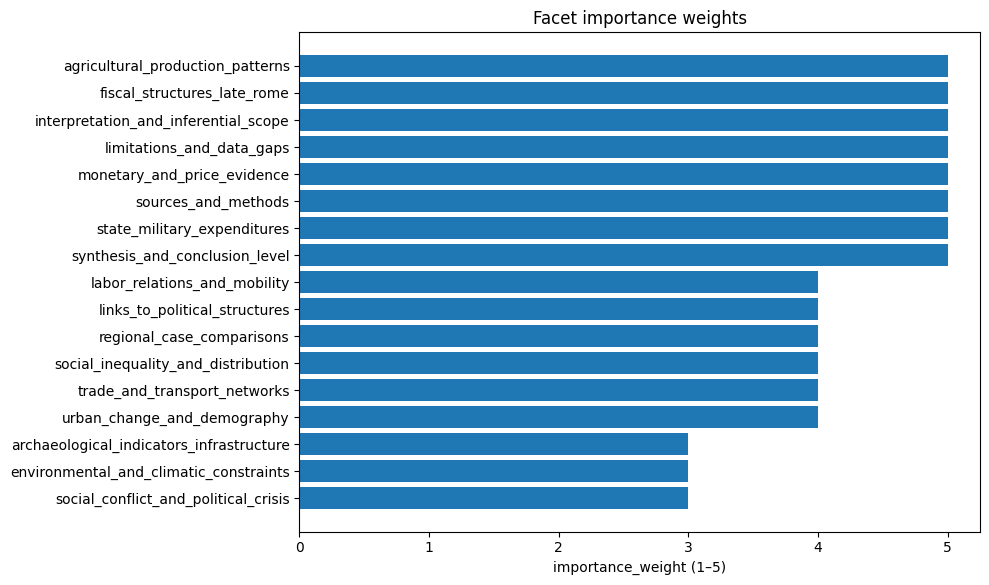

In [8]:
# Phase B.4 — Run the planner + inspect facets

try:
    import pandas as pd
except Exception:
    pd = None
    print("[WARN] pandas not available; facet table will be plain text. Install with: pip install pandas")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None
    print("[WARN] matplotlib not available; facet plot will be skipped. Install with: pip install matplotlib")


import textwrap


def _print_paragraph(text: str, width: int = 100) -> None:
    s = str(text or "").strip()
    if not s:
        print("<empty>")
        return
    print(textwrap.fill(s, width=width))


def _join_terms(terms, *, max_terms: int = 14, max_chars: int = 220) -> str:
    arr = [str(t).strip() for t in (terms or []) if str(t).strip()]
    s = ", ".join(arr[:max_terms])
    if len(arr) > max_terms:
        s = s + f", …(+{len(arr) - max_terms})"
    if len(s) > max_chars:
        s = s[: max_chars - 1] + "…"
    return s




chapter_input = ChapterInput(
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    pipeline_version=pipeline_version,
)

expected_run_id = chapter_input.compute_run_id()
if expected_run_id != run_ctx.run_id:
    print_section("Phase B.4 — Warning")
    print_kv(
        {
            "msg": "run_id mismatch; rebuilding Phase A context with current inputs",
            "expected_run_id": expected_run_id,
            "current_run_id": run_ctx.run_id,
        },
        key_width=16,
    )

    run_id = expected_run_id
    run_dir = cfg.runs_root / run_id

    artifacts = artifacts.model_copy(
        update={
            "query_plan_json": run_dir / "query_plan.json",
            "openalex_queries_json": run_dir / "openalex_queries.json",
            "semanticscholar_queries_json": run_dir / "semanticscholar_queries.json",
            "openalex_raw_jsonl": run_dir / "openalex_raw.jsonl",
            "semanticscholar_raw_jsonl": run_dir / "semanticscholar_raw.jsonl",
            "semanticscholar_recommendations_jsonl": run_dir / "semanticscholar_recommendations.jsonl",
            "candidates_normalized_jsonl": run_dir / "candidates_normalized.jsonl",
            "candidates_normalized_csv": run_dir / "candidates_normalized.csv",
            "embeddings_manifest_jsonl": run_dir / "embeddings_manifest.jsonl",
            "embeddings_manifest_csv": run_dir / "embeddings_manifest.csv",
            "embeddings_vectors_dir": run_dir / "embeddings_vectors",
            "rerank_results_jsonl": run_dir / "rerank_results.jsonl",
            "output_json": run_dir / "output.json",
            "logs_jsonl": run_dir / "logs.jsonl",
            "run_log": run_dir / "run.log",
            "metrics_json": run_dir / "metrics.json",
        }
    )

    run_ctx = RunContext(repo_root=REPO_ROOT, run_id=run_id, run_dir=run_dir, artifacts=artifacts)
    run_ctx.create_artifact_skeleton(overwrite=False)
    logger = setup_run_logger(run_ctx)


plan, meta = plan_queries_llm(
    chapter_input,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_QUERY_PLAN,
)

diag = meta.get("diagnostics") or diagnose_query_plan(plan)

print_section("Phase B.4 — Query Plan")
print_kv(
    {
        "cache_hit": meta.get("cache_hit"),
        "run_id": run_ctx.run_id,
        "run_dir": run_ctx.run_dir,
        "query_plan.json": run_ctx.artifacts.query_plan_json,
    },
    key_width=14,
)

print_section("Topic Summary (EN)")
_print_paragraph(plan.topic_summary_en)

print_section("Topic Summary (DE)")
_print_paragraph(plan.topic_summary_de)

# OpenAI usage + cost
print_section("OpenAI Usage / Cost")
if meta.get("cache_hit"):
    print("cache hit — no new tokens billed")
else:
    usage = meta.get("usage") or {}
    cost = meta.get("cost_estimate") or {}

    input_tokens = int(usage.get("input_tokens") or 0)
    cached_input_tokens = int(usage.get("cached_input_tokens") or 0)
    billable_input_tokens = max(input_tokens - min(cached_input_tokens, input_tokens), 0)

    print_kv(
        {
            "model_used": meta.get("model_used"),
            "latency_s": meta.get("latency_s"),
            "input_tokens": _fmt_int(input_tokens),
            "cached_input_tokens": _fmt_int(cached_input_tokens),
            "billable_input_tokens": _fmt_int(billable_input_tokens),
            "output_tokens": _fmt_int(int(usage.get("output_tokens") or 0)),
            "reasoning_tokens": _fmt_int(int(usage.get("reasoning_tokens") or 0)),
            "cost_usd": f"{float(cost.get('total_cost_usd') or 0.0):.6f}",
        },
        key_width=20,
    )

print_section("Facet Diagnostics")
print_kv(
    {
        "facet_count": diag.get("facet_count"),
        "issues": len(diag.get("issues") or []),
    },
    key_width=12,
)
if diag.get("issues"):
    print("\nIssues:")
    for x in diag["issues"]:
        print(f"- {x}")

rows = []
for f in plan.facets:
    rows.append(
        {
            "facet_id": f.facet_id,
            "weight": f.importance_weight,
            "facet_type": f.facet_type,
            "label_en": _truncate(f.facet_label_en, 80),
            "canon_en": len(f.canonical_terms.en),
            "canon_de": len(f.canonical_terms.de),
            "excl_en": len(f.exclusion_terms.en),
            "excl_de": len(f.exclusion_terms.de),
        }
    )

print_section("Facets")
if pd is not None:
    df = pd.DataFrame(rows).sort_values(["weight", "facet_id"], ascending=[False, True])
    display(df)
else:
    print_table(
        sorted(rows, key=lambda x: (-x["weight"], x["facet_id"])),
        columns=["facet_id", "weight", "facet_type", "label_en", "canon_en", "canon_de", "excl_en", "excl_de"],
        max_rows=200,
    )
print_section("Global Term Previews")
try:
    global_rows = [
        {
            "kind": "primary_context_anchors",
            "lang": "en",
            "n": len(plan.primary_context_anchors.en),
            "terms": _join_terms(plan.primary_context_anchors.en, max_terms=25, max_chars=260),
        },
        {
            "kind": "primary_context_anchors",
            "lang": "de",
            "n": len(plan.primary_context_anchors.de),
            "terms": _join_terms(plan.primary_context_anchors.de, max_terms=25, max_chars=260),
        },
        {
            "kind": "global_canonical_terms",
            "lang": "en",
            "n": len(plan.global_canonical_terms.en),
            "terms": _join_terms(plan.global_canonical_terms.en, max_terms=25, max_chars=260),
        },
        {
            "kind": "global_canonical_terms",
            "lang": "de",
            "n": len(plan.global_canonical_terms.de),
            "terms": _join_terms(plan.global_canonical_terms.de, max_terms=25, max_chars=260),
        },
        {
            "kind": "global_exclusions",
            "lang": "en",
            "n": len(plan.global_exclusions.en),
            "terms": _join_terms(plan.global_exclusions.en, max_terms=20, max_chars=260),
        },
        {
            "kind": "global_exclusions",
            "lang": "de",
            "n": len(plan.global_exclusions.de),
            "terms": _join_terms(plan.global_exclusions.de, max_terms=20, max_chars=260),
        },
    ]
    print_table(global_rows, columns=["kind", "lang", "n", "terms"], max_rows=20, max_col_width=260)
except Exception as e:
    print(f"[WARN] failed to print global term previews: {e}")


print_section("Facet Term Previews (Top facets)")
try:
    ordered_facets = sorted(
        plan.facets,
        key=lambda f: (-int(getattr(f, "importance_weight", 0) or 0), str(getattr(f, "facet_id", "") or "")),
    )
    preview_rows = []
    for f in ordered_facets[: min(12, len(ordered_facets))]:
        preview_rows.append(
            {
                "facet_id": f.facet_id,
                "weight": f.importance_weight,
                "canon_en": _join_terms(getattr(f.canonical_terms, "en", []) or [], max_terms=14, max_chars=220),
                "canon_de": _join_terms(getattr(f.canonical_terms, "de", []) or [], max_terms=14, max_chars=220),
                "excl_en": _join_terms(getattr(f.exclusion_terms, "en", []) or [], max_terms=10, max_chars=180),
                "excl_de": _join_terms(getattr(f.exclusion_terms, "de", []) or [], max_terms=10, max_chars=180),
            }
        )

    print_table(
        preview_rows,
        columns=["facet_id", "weight", "canon_en", "canon_de", "excl_en", "excl_de"],
        max_rows=50,
        max_col_width=220,
    )
except Exception as e:
    print(f"[WARN] failed to print facet term previews: {e}")



if plt is not None:
    plt.figure(figsize=(10, max(3, 0.35 * len(rows))))
    ordered = sorted(rows, key=lambda x: (-x["weight"], x["facet_id"]))
    ids = [r["facet_id"] for r in ordered]
    ws = [r["weight"] for r in ordered]
    plt.barh(ids, ws)
    plt.gca().invert_yaxis()
    plt.title("Facet importance weights")
    plt.xlabel("importance_weight (1–5)")
    plt.tight_layout()
    plt.show()


In [9]:
# Phase C — LLM: Provider-specific query generators (≤50/provider)

import json
import re
import unicodedata
from typing import Any, Dict, List, Literal, Optional, Tuple

from pydantic import BaseModel, Field
from pydantic.config import ConfigDict

# -----------------------------
# Phase C.0 — Provider query models (strict)
# -----------------------------


class OpenAlexQuery(BaseModel):
    model_config = ConfigDict(extra="forbid")

    intent: Literal["authority", "match"]
    language: Literal["en", "de"]
    search_field: Literal["default.search", "title_and_abstract.search"] = "title_and_abstract.search"
    query_string: str
    filters: str
    sort: Optional[Literal["cited_by_count:desc", "relevance_score:desc"]] = None
    per_page: int = Field(default=200)
    notes: str


class S2BulkQuery(BaseModel):
    model_config = ConfigDict(extra="forbid")

    intent: Literal["authority", "match"]
    language: Literal["en", "de"]
    query_string: str
    notes: str


OPENALEX_QUERY_BUILDER_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["openalex_queries"],
    "properties": {
        "openalex_queries": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["intent", "language", "search_field", "query_string", "filters", "sort", "per_page", "notes"],
                "properties": {
                    "intent": {"type": "string", "enum": ["authority", "match"]},
                    "language": {"type": "string", "enum": ["en", "de"]},
                    "search_field": {"type": "string", "enum": ["default.search", "title_and_abstract.search"]},
                    "query_string": {"type": "string"},
                    "filters": {"type": "string"},
                    "sort": {
                        "anyOf": [
                            {"type": "string", "enum": ["cited_by_count:desc", "relevance_score:desc"]},
                            {"type": "null"},
                        ]
                    },
                    "per_page": {"type": "integer", "enum": [200]},
                    "notes": {"type": "string"},
                },
            },
        }
    },
}


S2_BULK_QUERY_BUILDER_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["s2_bulk_queries"],
    "properties": {
        "s2_bulk_queries": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["intent", "language", "query_string", "notes"],
                "properties": {
                    "intent": {"type": "string", "enum": ["authority", "match"]},
                    "language": {"type": "string", "enum": ["en", "de"]},
                    "query_string": {"type": "string"},
                    "notes": {"type": "string"},
                },
            },
        }
    },
}

# -----------------------------
# Phase C.1 — Prompt templates (from the implementation plan)
# -----------------------------

OPENALEX_QUERY_BUILDER_SYSTEM_PROMPT = """You generate OpenAlex /works query objects. Output ONLY valid JSON.
Goal: high precision with strong recall across ANY scientific domain.
Be deterministic.
"""

OPENALEX_QUERY_BUILDER_USER_PROMPT_TEMPLATE = """PIPELINE CONTEXT (READ CAREFULLY):
You generate provider-safe OpenAlex /works query objects for retrieval in a two-lane pipeline.
These queries only collect candidates; downstream stages deduplicate, embed, and rerank.
So: keep queries context-anchored and selective, but not ultra-narrow.

CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC_TEXT:
{{chapter_spec_text}}

INPUT_QUERY_PLAN_JSON:
{{query_plan_json}}

BUDGET:
max_queries = {{max_queries}}  # hard cap
languages = ["en","de"]

KONTEXT:
CHAPTER_TITLE is the titel of a chapter that I want to write in my paper and CHAPTER_SPEC_TEXT is a text that describes exactly what the chapter
should be about. This is one step in a pipeline to find the best sources to write that chapter in my paper about. 

GOALS:
Return OpenAlex /works query objects supporting:
- authority intent: canonical/high-impact core literature (still context-anchored)
- match intent: best topical fit, including strong partial matches on facets

OPENALEX BOOLEAN RULES (MANDATORY):
- AND/OR/NOT must be UPPERCASE
- Parentheses and quotes allowed
- Forbidden: * ? ~ (never output these)
- Avoid slash tokens X/Y; write (X OR Y) instead

OUTPUT JSON SCHEMA:
{
  "openalex_queries": [
    {
      "intent": "authority" | "match",
      "language": "en" | "de",
      "search_field": "default.search" | "title_and_abstract.search",
      "query_string": "BOOLEAN QUERY STRING",
      "filters": "comma,separated,filters",
      "sort": "cited_by_count:desc" | "relevance_score:desc" | null,
      "per_page": 200,
      "notes": "<= 18 words"
    }
  ]
}

MANDATORY RULES:
1) Every query MUST include at least ONE term from primary_context_anchors[language].
2) TERM HYGIENE: do not output any term containing parentheses, commas, “e.g.”, “z. B.”, or explanatory text.
3) EXCLUSIONS:
   - Only use atomic exclusion terms (<=3 words, no punctuation except hyphen).
   - If exclusions violate this, OMIT exclusions rather than writing narrative NOT clauses.
4) search_field policy:
   - match -> "title_and_abstract.search"
   - authority -> "title_and_abstract.search" for most queries, plus optionally 1 booster per language using "default.search" for extra recall.
5) filters MUST include: is_paratext:false, is_retracted:false, language:<en|de>
6) Authority lane MUST include per language:
   - one broad authority query WITHOUT is_core filter
   - optionally one booster query WITH primary_location.source.is_core:true
7) Sorting:
   - authority: cited_by_count:desc
   - match: relevance_score:desc or null

FILTER POLICY:
- Only use comma-separated filters (no semicolons).
- Only use safe keys:
  language,is_paratext,is_retracted,type,from_publication_date,to_publication_date,
  primary_location.source.is_core,locations.source.is_core

BUDGETING (DETERMINISTIC):
- authority: 2 queries (EN+DE) + up to 2 is_core boosters (EN+DE)
- match: global match EN+DE
- match: for each facet with weight>=4 -> 1 EN + 1 DE query
- if budget remains -> 6 extra queries total across neighbor/method facets

QUERY SHAPES (MIX REQUIRED FOR MATCH):
- STRICT: (anchor1 AND anchor2) AND (facet OR-group)
- BALANCED: (anchor OR anchor_variant...) AND (facet OR-group)
- FACET-LED: (anchor) AND (facet OR-group with 8–12 terms)
Ensure at least 25% FACET-LED and at least 25% BALANCED among match queries.

SELF-CHECK (must enforce silently):
- No * ? ~
- AND/OR/NOT uppercase
- No slash tokens X/Y
- Every query includes a primary_context_anchors term
- Exclusions are atomic or omitted
- Filters are comma-separated and safe
If anything fails, fix it and output corrected JSON only.

Return ONLY JSON.
"""


S2_BULK_QUERY_BUILDER_SYSTEM_PROMPT = """You generate Semantic Scholar Academic Graph bulk search queries for scientific literature retrieval.
Output ONLY valid JSON that matches the given schema. No prose.
Be deterministic and conservative: prefer correctness and anchoring over breadth.
Never mix context anchors and facet terms in the same OR-group."""


S2_BULK_QUERY_BUILDER_USER_PROMPT_TEMPLATE = """CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC_TEXT:
{{chapter_spec_text}}

INPUT_QUERY_PLAN_JSON:
{{query_plan_json}}

BUDGET:
max_queries = {{max_queries}}
languages = ["en","de"]

OUTPUT JSON:
{
  "s2_bulk_queries": [
    {
      "intent": "authority" | "match",
      "language": "en" | "de",
      "query_string": "QUERY STRING",
      "notes": "<= 18 words"
    }
  ]
}

CONTEXT:
CHAPTER_TITLE is the title of a chapter in a scientific paper.
CHAPTER_SPEC_TEXT describes exactly what information the chapter must cover.
Your job: produce provider-safe Semantic Scholar BULK search queries that retrieve relevant literature candidates.

ALLOWED OPERATORS (ONLY THESE):
- Required: +term or +("a" | "b")
- Exclude: -term or -"phrase"
- OR: ("a" | "b" | "c")  # ALL | MUST be inside parentheses
- Quotes: "two words"
- Wildcard: suffix only, e.g. gene*  (GUARDRAIL: stem length >=4)
- Fuzzy/edit distance: term~1 or term~2 (GUARDRAIL: N<=2 unless term length>=8; then N<=3)
- Phrase proximity: "two word phrase" ~2..4 (GUARDRAIL: N<=4)

ABSOLUTE SEPARATION RULE (CRITICAL; DO NOT VIOLATE):
A) PRIMARY_CONTEXT terms and FACET terms MUST NEVER be mixed in the same OR-group.
B) PRIMARY_CONTEXT_OR_GROUP MUST be built ONLY from primary_context_anchors for that language.
C) FACET_OR_GROUP MUST be built ONLY from facet canonical_terms + neighbor_terms (plus safe bilingual variants).
D) If a term is not explicitly in primary_context_anchors, it is NOT allowed in PRIMARY_CONTEXT_OR_GROUP.

Examples of WRONG primary context groups (do NOT do this):
- +("Late Antiquity" | taxation | coinage)      # taxation/coinage are facet terms, not anchors
- +("Spätantike" | "öffentliche Finanzen")      # public finance is a facet term
- +("COVID-19" | "randomized trial")            # randomized trial is method/facet, not context anchor

MANDATORY STRUCTURE:

MATCH queries MUST have:
  +(PRIMARY_CONTEXT_OR_GROUP) +(FACET_OR_GROUP) [optional NEGATIVES]

Recommended stronger MATCH form (use when possible):
  +(PRIMARY_CONTEXT_OR_GROUP) +(SECOND_CONTEXT_OR_GROUP) +(FACET_OR_GROUP) [optional NEGATIVES]

PRIMARY_CONTEXT_OR_GROUP:
- Parenthesized OR-group of 2–6 terms taken ONLY from primary_context_anchors[language].
- Must include at least 2 distinct anchors when available.

SECOND_CONTEXT_OR_GROUP (optional but recommended when it reduces drift):
- Parenthesized OR-group of 2–6 terms taken ONLY from primary_context_anchors OR global_canonical_terms that are ALSO true context anchors.
- NEVER include facet terms here.

FACET_OR_GROUP:
- Parenthesized OR-group of 5–12 terms from the target facet's canonical_terms + neighbor_terms.
- May include bilingual variants inside the facet group ONLY (to improve recall).

AMBIGUOUS TERM HYGIENE (CRITICAL ANTI-DRIFT):
Some tokens are highly ambiguous across science (examples: coinage, currency, finance, growth, model, system, dynamics, metals).
If such an ambiguous token appears in FACET_OR_GROUP, you MUST:
- replace it with a more specific phrase (e.g. "Roman coinage", "ancient coinage") OR
- pair it with 1–3 disambiguating facet terms in the same group (e.g. numismatic, hoard, mint, denarius/solidus; or domain equivalents).
Never use ambiguous standalone tokens in a way that can match unrelated fields (e.g. "coinage" matching "coinage metals").

EXCLUSIONS (NEGATIVES):
- Use at most 3 negatives per query, only if they prevent wrong senses.
- Atomic negatives ONLY: <=3 words, no commas, no parentheses, no “e.g.”.
- Format: -term or -"two words"
- Do not use OR inside negatives.

AUTHORITY POLICY:
Authority queries are broader but MUST remain anchored:
  +(PRIMARY_CONTEXT_OR_GROUP) +(HIGH_LEVEL_OR_GROUP) [optional NEGATIVES]

HIGH_LEVEL_OR_GROUP:
- Topic-specific terms only: pick from global_canonical_terms and/or weight>=4 facets.
- MUST NOT be generic standalone econ/method words (e.g., "public finance", "currency", "policy") unless paired with disambiguating terms that keep it inside the chapter context.

Also include ONE bilingual fallback authority query:
  +("DE primary anchor" | "EN primary anchor") +(HIGH_LEVEL_OR_GROUP)

BUDGETING (DETERMINISTIC):
- Always: authority EN + authority DE + authority bilingual fallback
- Always: global match EN + global match DE
- For each facet with weight>=4: match EN + match DE
- If budget exceeded: drop lowest-weight facets first, keep bilingual authority fallback.

SELF-CHECK (MUST DO, FIX SILENTLY):
- PRIMARY_CONTEXT_OR_GROUP contains ONLY primary_context_anchors terms (no facet terms).
- FACET_OR_GROUP contains ONLY facet canonical/neighbor terms (plus bilingual variants).
- Every '|' is inside parentheses.
- Wildcard only suffix and stem>=4.
- ~ only within allowed N.
- MATCH has >=2 required groups (+(...) +(...)).
- No slash tokens X/Y (rewrite as ("X" | "Y")).
If any check fails, regenerate and output corrected JSON only.

Return ONLY JSON: { "s2_bulk_queries": [ ... ] }
"""


# -----------------------------
# Phase C.2 — Deterministic validators + normalizers
# -----------------------------

OPENALEX_ALLOWED_FILTER_KEYS = {
    "language",
    "is_paratext",
    "is_retracted",
    "type",
    "from_publication_date",
    "to_publication_date",
    "primary_location.source.is_core",
    "locations.source.is_core",
}


def _render_template(template: str, **vars: str) -> str:
    s = template
    for k, v in vars.items():
        s = s.replace("{{" + k + "}}", str(v))
    return s


def _json_for_prompt(obj: Any) -> str:
    return json.dumps(obj, ensure_ascii=False, indent=2)


def _sanitize_plan_for_query_builders(plan: QueryPlan) -> Dict[str, Any]:
    obj = plan.model_dump(mode="json")
    try:
        ge = obj.get("global_exclusions") or {}
        for lang in ("en", "de"):
            terms = list(ge.get(lang) or [])
            ge[lang] = [t for t in terms if _is_atomic_exclusion(t)]
        obj["global_exclusions"] = ge

        facets = obj.get("facets") or []
        for f in facets:
            ex = f.get("exclusion_terms") or {}
            for lang in ("en", "de"):
                terms = list(ex.get(lang) or [])
                ex[lang] = [t for t in terms if _is_atomic_exclusion(t)]
            f["exclusion_terms"] = ex
    except Exception:
        return obj
    return obj


def _limit_words(text: str, max_words: int) -> str:
    s = str(text or "").strip()
    if not s:
        return ""
    words = re.split(r"\s+", s)
    if len(words) <= int(max_words):
        return s
    return " ".join(words[: int(max_words)]).strip()


def _truncate_chars(text: str, max_chars: int) -> str:
    s = str(text or "").strip()
    if len(s) <= int(max_chars):
        return s
    head = s[: int(max_chars)].rstrip()
    return head + "\n...[TRUNCATED]..."


_BAD_EXCL_PAT = re.compile(r"(e\.g\.|z\.\s*b\.|,|\(|\)|;|:)", re.IGNORECASE)


def _is_atomic_exclusion(term: str) -> bool:
    t = str(term or "").strip()
    if not t:
        return False
    if _BAD_EXCL_PAT.search(t):
        return False
    if len(t) > 40:
        return False
    if len(t.split()) > 3:
        return False
    # No punctuation except hyphen (Unicode word chars are allowed; '_' is treated as punctuation here).
    if "_" in t:
        return False
    if re.search(r"[^\w\s-]", t, flags=re.UNICODE):
        return False
    return True


def _lint_openalex_not_clauses_atomic(qs: str) -> None:
    s = str(qs or "")
    if "NOT" not in s:
        return

    # Identify NOT clauses outside quotes and validate all term candidates inside them.
    in_quote = False
    i = 0
    clauses: List[str] = []

    def _is_word_boundary(pos: int) -> bool:
        if pos < 0 or pos >= len(s):
            return True
        return not (s[pos].isalnum() or s[pos] == "_")

    while i < len(s):
        ch = s[i]
        if ch == '"':
            in_quote = not in_quote
            i += 1
            continue
        if not in_quote and s.startswith("NOT", i) and _is_word_boundary(i - 1) and _is_word_boundary(i + 3):
            j = i + 3
            while j < len(s) and s[j].isspace():
                j += 1
            if j >= len(s):
                break
            if s[j] == "(":
                depth = 1
                k = j + 1
                in_q2 = False
                while k < len(s) and depth > 0:
                    if s[k] == '"':
                        in_q2 = not in_q2
                        k += 1
                        continue
                    if not in_q2:
                        if s[k] == "(":
                            depth += 1
                        elif s[k] == ")":
                            depth -= 1
                    k += 1
                clauses.append(s[j:k])
                i = k
                continue
            if s[j] == '"':
                k = j + 1
                while k < len(s) and s[k] != '"':
                    k += 1
                clauses.append(s[j : min(k + 1, len(s))])
                i = min(k + 1, len(s))
                continue
            k = j
            while k < len(s) and not s[k].isspace():
                k += 1
            clauses.append(s[j:k])
            i = k
            continue
        i += 1

    if not clauses:
        return

    bad: List[str] = []
    for clause in clauses:
        # Quoted phrases
        for m in re.finditer(r'"([^"]+)"', clause):
            term = m.group(1).strip()
            if not _is_atomic_exclusion(term):
                bad.append(term)
        # Bare tokens (ignore boolean ops)
        for tok in re.findall(r"[\w-]+", clause, flags=re.UNICODE):
            if tok.upper() in {"AND", "OR", "NOT"}:
                continue
            if not _is_atomic_exclusion(tok):
                bad.append(tok)

    if bad:
        raise ValueError(f"OpenAlex: non-atomic exclusions in NOT clause: {bad[:6]}")


def _lint_s2_negative_terms_atomic(qs: str) -> None:
    s = str(qs or "")
    bad: List[str] = []
    for m in re.finditer(r'-(\"[^\"]+\"|[^\s()|]+)', s):
        raw = m.group(1).strip()
        if raw.startswith('"') and raw.endswith('"') and len(raw) >= 2:
            raw = raw[1:-1].strip()
        if not _is_atomic_exclusion(raw):
            bad.append(raw)
    if bad:
        raise ValueError(f"S2: non-atomic negative terms: {bad[:6]}")


def _validate_s2_advanced_ops(qs: str) -> None:
    s = str(qs or "")

    # wildcard: allow only suffix token like abc*
    for m in re.finditer(r"(\S+)\*", s):
        stem = m.group(1)
        stem = stem.strip().strip('"()')
        stem = re.sub(r"^[+\-]+", "", stem)
        if len(stem) < 4:
            raise ValueError(f"S2: wildcard stem too short: {m.group(0)!r}")
        # suffix only: reject if immediately followed by a word char (e.g. gene*foo)
        if m.end() < len(s) and re.match(r"\w", s[m.end() : m.end() + 1]):
            raise ValueError(f"S2: wildcard must be suffix: {m.group(0)!r}")

    # fuzzy: term~N
    for m in re.finditer(r"(\w+)~(\d+)", s):
        term, n = m.group(1), int(m.group(2))
        if n > 3:
            raise ValueError(f"S2: fuzzy too large: {m.group(0)!r}")
        if n == 3 and len(term) < 8:
            raise ValueError(f"S2: ~3 only for long terms: {m.group(0)!r}")

    # phrase proximity: "a b" ~N
    for m in re.finditer(r'"[^"]+"\s*~\s*(\d+)', s):
        n = int(m.group(1))
        if n > 4:
            raise ValueError(f"S2: proximity too large: {m.group(0)!r}")


_UNICODE_INVISIBLE_CHARS = [
    "\u200b",  # zero width space
    "\u200c",  # zero width non-joiner
    "\u200d",  # zero width joiner
    "\u2060",  # word joiner
    "\ufeff",  # zero width no-break space / BOM
]

_UNICODE_HYPHEN_CHARS = [
    "\u2010",  # hyphen
    "\u2011",  # non-breaking hyphen
    "\u2012",  # figure dash
    "\u2013",  # en dash
    "\u2014",  # em dash
    "\u2212",  # minus sign
    "\ufe58",  # small em dash
    "\ufe63",  # small hyphen-minus
    "\uff0d",  # fullwidth hyphen-minus
]


def _normalize_unicode_query_text(text: str) -> str:
    s = str(text or "")
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("\u00a0", " ")  # NBSP -> space
    s = s.replace("\u00ad", "")  # soft hyphen -> remove
    for ch in _UNICODE_INVISIBLE_CHARS:
        s = s.replace(ch, "")
    for ch in _UNICODE_HYPHEN_CHARS:
        s = s.replace(ch, "-")
    return s


def _quote_term(term: str) -> str:
    t = str(term or "").strip()
    if t.startswith('"') and t.endswith('"') and len(t) >= 2:
        t = t[1:-1].strip()
    t = t.replace('"', "")
    return f"\"{t}\""


def _expand_slash_tokens(text: str, *, or_operator: str) -> str:
    s = str(text or "")
    if "/" not in s:
        return s

    def _make_or_group(value: str) -> Optional[str]:
        if "://" in value:
            return None
        if re.search(r"\b10\.\d{4,9}/\S+\b", value):
            return None

        parts = [p.strip() for p in str(value or "").split("/") if p.strip()]
        if len(parts) < 2:
            return None
        if all(p.lower() in {"and", "or", "not"} for p in parts):
            return None

        return "(" + f" {or_operator} ".join(_quote_term(p) for p in parts) + ")"

    # Rewrite inside quotes first:  "roads/bridges" -> ("roads" OR "bridges")
    def _repl_quoted(m: re.Match[str]) -> str:
        inner = m.group(1)
        group = _make_or_group(inner)
        return group if group is not None else m.group(0)

    s = re.sub(r"\"([^\"]*?/[^\"\n]*)\"", _repl_quoted, s)

    # Then rewrite bare tokens outside quotes.
    token_re = re.compile(r"(?P<tok>[\w][\w\.-]*/[\w][\w\.-]*(?:/[\w][\w\.-]*)*)", flags=re.UNICODE)

    def _rewrite_segment(seg: str) -> str:
        def _repl_tok(m: re.Match[str]) -> str:
            tok = m.group("tok")
            group = _make_or_group(tok)
            return group if group is not None else tok

        return token_re.sub(_repl_tok, seg)

    out: List[str] = []
    buf: List[str] = []
    in_quote = False

    for ch in s:
        if ch == '"':
            seg = "".join(buf)
            out.append(seg if in_quote else _rewrite_segment(seg))
            buf.clear()
            out.append('"')
            in_quote = not in_quote
            continue
        buf.append(ch)

    seg = "".join(buf)
    out.append(seg if in_quote else _rewrite_segment(seg))
    return "".join(out)


def _uppercase_boolean_ops_outside_quotes(text: str) -> str:
    s = str(text or "")
    out: List[str] = []
    buf: List[str] = []
    in_quote = False

    def flush_buf():
        seg = "".join(buf)
        if not in_quote:
            seg = re.sub(r"\b(and|or|not)\b", lambda m: m.group(1).upper(), seg, flags=re.IGNORECASE)
        out.append(seg)
        buf.clear()

    for ch in s:
        if ch == '"':
            flush_buf()
            out.append('"')
            in_quote = not in_quote
            continue
        buf.append(ch)

    flush_buf()
    return "".join(out)


def _parse_filters(filters: str) -> List[str]:
    return [p.strip() for p in str(filters or "").split(",") if p.strip()]


def _canonicalize_openalex_filters(filters: str, *, language: str) -> str:
    parts = _parse_filters(filters)
    seen = set()
    cleaned: List[str] = []

    for p in parts:
        if ":" not in p:
            raise ValueError(f"OpenAlex filter missing ':': {p!r}")
        key = p.split(":", 1)[0].strip()
        if key not in OPENALEX_ALLOWED_FILTER_KEYS:
            raise ValueError(f"OpenAlex filter key not allowed: {key!r} (filter={p!r})")
        if key == "language":
            p = f"language:{language}"
        if p not in seen:
            cleaned.append(p)
            seen.add(p)

    required = ["is_paratext:false", "is_retracted:false", f"language:{language}"]
    tail = [p for p in cleaned if p not in required and not p.startswith("language:")]
    return ",".join(required + tail)


def _normalize_openalex_query(q: OpenAlexQuery) -> OpenAlexQuery:
    qs = _normalize_unicode_query_text(str(q.query_string or "")).strip()
    if any(ch in qs for ch in ("*", "?", "~")):
        raise ValueError(f"OpenAlex forbidden character in query_string: {qs!r}")
    qs = _expand_slash_tokens(qs, or_operator="OR")
    qs = _uppercase_boolean_ops_outside_quotes(qs)
    qs = re.sub(r"\s+", " ", qs).strip()
    _lint_openalex_not_clauses_atomic(qs)

    filters = _canonicalize_openalex_filters(q.filters, language=q.language)

    search_field = getattr(q, "search_field", None) or "title_and_abstract.search"
    if q.intent == "match":
        search_field = "title_and_abstract.search"
    elif search_field not in ("default.search", "title_and_abstract.search"):
        search_field = "title_and_abstract.search"

    sort = q.sort
    if q.intent == "authority":
        sort = "cited_by_count:desc"
    elif q.intent == "match":
        if sort not in (None, "relevance_score:desc"):
            sort = "relevance_score:desc"

    notes = _limit_words(q.notes, 18)

    return q.model_copy(
        update={
            "search_field": search_field,
            "query_string": qs,
            "filters": filters,
            "sort": sort,
            "per_page": 200,
            "notes": notes,
        }
    )


def _normalize_s2_query(q: S2BulkQuery) -> S2BulkQuery:
    qs = _normalize_unicode_query_text(str(q.query_string or ""))
    qs = _expand_slash_tokens(qs.strip(), or_operator="|")
    qs = re.sub(r"\s+", " ", qs)
    if "?" in qs:
        raise ValueError(f"S2 forbidden character in query_string: {qs!r}")
    _validate_s2_advanced_ops(qs)
    _lint_s2_negative_terms_atomic(qs)
    if not re.search(r"\+\s*(?:\(|\")", qs):
        raise ValueError(f"S2 query_string must contain at least one +anchor: {qs!r}")

    plus_count = len(re.findall(r"(?:^|\s)\+", qs))
    if q.intent == "match" and plus_count < 2:
        raise ValueError(f"S2 match query_string must contain >=2 required components (+): {qs!r}")

    depth = 0
    in_quote = False
    for ch in qs:
        if ch == '"':
            in_quote = not in_quote
            continue
        if in_quote:
            continue
        if ch == "(":
            depth += 1
        elif ch == ")":
            depth = max(depth - 1, 0)
        elif ch == "|" and depth <= 0:
            raise ValueError(f"S2 operator sanity: '|' must be inside parentheses: {qs!r}")

    notes = _limit_words(q.notes, 18)
    return q.model_copy(update={"query_string": qs.strip(), "notes": notes})


def _validate_language_coverage(queries: List[Any], *, provider: str) -> None:
    langs = sorted({getattr(q, "language", None) for q in queries})
    if "en" not in langs or "de" not in langs:
        raise ValueError(f"{provider}: expected both languages en+de, got {langs}")


def _validate_intent_coverage(queries: List[Any], *, provider: str) -> None:
    intents = sorted({getattr(q, "intent", None) for q in queries})
    if "authority" not in intents or "match" not in intents:
        raise ValueError(f"{provider}: expected both intents authority+match, got {intents}")


def _find_anchor_terms_in_text(text: str, terms: List[str]) -> List[str]:
    hay = _normalize_unicode_query_text(str(text or "")).lower()
    matches: List[str] = []
    for t in terms:
        tt = _normalize_unicode_query_text(str(t or "")).strip()
        if not tt:
            continue
        if tt.lower() in hay:
            matches.append(tt)

    matches.sort(key=lambda x: len(x), reverse=True)

    seen = set()
    uniq: List[str] = []
    for m in matches:
        key = m.lower()
        if key in seen:
            continue
        uniq.append(m)
        seen.add(key)
    return uniq


def _validate_openalex_anchor_presence(queries: List[OpenAlexQuery], *, plan: QueryPlan) -> None:
    for q in queries:
        anchors = getattr(plan.primary_context_anchors, q.language, []) or []
        if not anchors:
            continue
        hits = _find_anchor_terms_in_text(q.query_string, list(anchors))
        if not hits:
            raise ValueError(f"OpenAlex: query missing required anchor (lang={q.language}, intent={q.intent}): {q.query_string!r}")


def _validate_s2_anchor_presence(queries: List[S2BulkQuery], *, plan: QueryPlan) -> None:
    for q in queries:
        anchors = getattr(plan.primary_context_anchors, q.language, []) or []
        if not anchors:
            continue
        hits = _find_anchor_terms_in_text(q.query_string, list(anchors))
        if not hits:
            raise ValueError(f"S2: query missing required primary anchor (lang={q.language}, intent={q.intent}): {q.query_string!r}")


def _validate_openalex_match_anchor_fingerprint_diversity(
    queries: List[OpenAlexQuery],
    *,
    plan: QueryPlan,
    max_share: float = 0.60,
) -> None:
    for lang in ("en", "de"):
        anchors = getattr(plan.primary_context_anchors, lang, []) or []
        anchors = [t for t in anchors if str(t or "").strip()]
        if not anchors:
            continue

        match_qs = [q for q in queries if q.intent == "match" and q.language == lang]
        if len(match_qs) < 4:
            continue

        counts: Dict[Tuple[str, str], int] = {}
        eligible = 0
        for q in match_qs:
            hits = _find_anchor_terms_in_text(q.query_string, anchors)
            top2 = [h.lower() for h in hits[:2]]
            if len(top2) < 2:
                continue
            fp = (top2[0], top2[1])
            counts[fp] = counts.get(fp, 0) + 1
            eligible += 1

        if eligible < 4:
            continue

        most_fp, most_n = max(counts.items(), key=lambda kv: kv[1])
        share = most_n / max(eligible, 1)
        if share > float(max_share):
            raise ValueError(
                f"OpenAlex: anchor fingerprint concentration too high (lang={lang}, share={share:.2f}, fp={most_fp}): regenerate"
            )

# -----------------------------
# Phase C.3 — LLM query builders with caching
# -----------------------------


def build_openalex_queries_llm(
    plan: QueryPlan,
    *,
    chapter_title: str = "",
    chapter_spec_text: str = "",
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[List[OpenAlexQuery], Dict[str, Any]]:
    stage = "phase_c_openalex_query_builder"
    cache_path = run_ctx.artifacts.openalex_queries_json

    def _load_cache() -> Optional[List[OpenAlexQuery]]:
        if not cache_path.exists():
            return None
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
                return None

            items = cached_obj.get("openalex_queries")
            if not isinstance(items, list):
                raise ValueError("cache missing openalex_queries list")

            queries = [_normalize_openalex_query(OpenAlexQuery.model_validate(x)) for x in items]

            max_q = int(config.max_queries_per_provider or 0) or 50
            if len(queries) > max_q:
                queries = queries[:max_q]

            _validate_language_coverage(queries, provider="OpenAlex")
            _validate_intent_coverage(queries, provider="OpenAlex")
            _validate_openalex_anchor_presence(queries, plan=plan)
            _validate_openalex_match_anchor_fingerprint_diversity(queries, plan=plan)

            write_json(cache_path, {"openalex_queries": [q.model_dump(mode="json") for q in queries]})
            log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path), query_count=len(queries))
            return queries

        except Exception as e:
            err = str(e)
            write_json(
                run_ctx.run_dir / "openalex_queries.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err[:800])
            return None

    if not force_rebuild:
        cached = _load_cache()
        if cached is not None:
            meta = {
                "cache_hit": True,
                "usage": {"input_tokens": 0, "cached_input_tokens": 0, "output_tokens": 0, "reasoning_tokens": 0},
                "cost_estimate": {"total_cost_usd": 0.0},
                "query_count": len(cached),
            }
            return cached, meta

    query_plan_json = _json_for_prompt(_sanitize_plan_for_query_builders(plan))
    max_q = int(config.max_queries_per_provider or 0) or 50

    user_prompt = _render_template(
        OPENALEX_QUERY_BUILDER_USER_PROMPT_TEMPLATE,
        chapter_title=str(chapter_title or "").strip(),
        chapter_spec_text=_truncate_chars(chapter_spec_text, 12000),
        query_plan_json=query_plan_json,
        max_queries=str(max_q),
    )

    max_attempts = 3
    last_err: Optional[Exception] = None
    obj: Dict[str, Any] = {}
    meta: Dict[str, Any] = {}
    queries: List[OpenAlexQuery] = []

    with stage_timer(run_ctx, stage):
        for attempt in range(1, max_attempts + 1):
            debug_prefix = f"openalex_queries_attempt{attempt}"
            attempt_prompt = user_prompt
            if last_err is not None:
                attempt_prompt = (
                    user_prompt
                    + "\n\nLINT_FEEDBACK:\n- Previous attempt failed deterministic validation. Fix and regenerate.\n"
                    + f"- Error: {str(last_err)[:400]}\n"
                )

            try:
                obj, meta = openai_json_schema_call(
                    api_key=config.openai_api_key or "",
                    model=config.openai_model_planner,
                    system_prompt=OPENALEX_QUERY_BUILDER_SYSTEM_PROMPT,
                    user_prompt=attempt_prompt,
                    schema_name="openalex_queries",
                    schema=OPENALEX_QUERY_BUILDER_JSON_SCHEMA,
                    reasoning_effort=config.openai_reasoning_effort,
                    max_output_tokens=8000,
                    timeout_s=config.openai_timeout_s,
                    debug_dir=run_ctx.run_dir,
                    debug_prefix=debug_prefix,
                )
            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="openai_call_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                )
                if attempt >= max_attempts:
                    raise
                continue

            attempt_raw_path = run_ctx.run_dir / f"{debug_prefix}.raw_output.json"
            attempt_meta_path = run_ctx.run_dir / f"{debug_prefix}.openai_meta.json"
            write_json(attempt_raw_path, obj)
            write_json(attempt_meta_path, meta)

            try:
                items = obj.get("openalex_queries")
                if not isinstance(items, list):
                    raise ValueError("OpenAI output missing openalex_queries list")
                queries = [_normalize_openalex_query(OpenAlexQuery.model_validate(x)) for x in items]

                if len(queries) > max_q:
                    log_event(run_ctx, stage=stage, event="budget_trim", from_count=len(queries), to_count=max_q)
                    queries = queries[:max_q]

                _validate_language_coverage(queries, provider="OpenAlex")
                _validate_intent_coverage(queries, provider="OpenAlex")
                _validate_openalex_anchor_presence(queries, plan=plan)
                _validate_openalex_match_anchor_fingerprint_diversity(queries, plan=plan)

                # Success: keep stable "latest" files for downstream cells.
                write_json(run_ctx.run_dir / "openalex_queries.raw_output.json", obj)
                write_json(run_ctx.run_dir / "openalex_queries.openai_meta.json", meta)
                break

            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="lint_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                    raw_path=str(attempt_raw_path),
                )
                if attempt >= max_attempts:
                    raise
                continue

    write_json(cache_path, {"openalex_queries": [q.model_dump(mode="json") for q in queries]})
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
        query_count=len(queries),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    metrics["stages"][stage]["query_count"] = len(queries)
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["query_count"] = len(queries)
    return queries, meta


def build_s2_bulk_queries_llm(
    plan: QueryPlan,
    *,
    chapter_title: str = "",
    chapter_spec_text: str = "",
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[List[S2BulkQuery], Dict[str, Any]]:
    stage = "phase_c_s2_query_builder"
    cache_path = run_ctx.artifacts.semanticscholar_queries_json

    def _load_cache() -> Optional[List[S2BulkQuery]]:
        if not cache_path.exists():
            return None
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
                return None

            items = cached_obj.get("s2_bulk_queries")
            if not isinstance(items, list):
                raise ValueError("cache missing s2_bulk_queries list")

            queries = [_normalize_s2_query(S2BulkQuery.model_validate(x)) for x in items]

            max_q = int(config.max_queries_per_provider or 0) or 50
            if len(queries) > max_q:
                queries = queries[:max_q]

            _validate_language_coverage(queries, provider="S2")
            _validate_intent_coverage(queries, provider="S2")
            _validate_s2_anchor_presence(queries, plan=plan)

            write_json(cache_path, {"s2_bulk_queries": [q.model_dump(mode="json") for q in queries]})
            log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path), query_count=len(queries))
            return queries

        except Exception as e:
            err = str(e)
            write_json(
                run_ctx.run_dir / "s2_bulk_queries.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err[:800])
            return None

    if not force_rebuild:
        cached = _load_cache()
        if cached is not None:
            meta = {
                "cache_hit": True,
                "usage": {"input_tokens": 0, "cached_input_tokens": 0, "output_tokens": 0, "reasoning_tokens": 0},
                "cost_estimate": {"total_cost_usd": 0.0},
                "query_count": len(cached),
            }
            return cached, meta

    query_plan_json = _json_for_prompt(_sanitize_plan_for_query_builders(plan))
    max_q = int(config.max_queries_per_provider or 0) or 50

    user_prompt = _render_template(
        S2_BULK_QUERY_BUILDER_USER_PROMPT_TEMPLATE,
        chapter_title=str(chapter_title or "").strip(),
        chapter_spec_text=_truncate_chars(chapter_spec_text, 12000),
        query_plan_json=query_plan_json,
        max_queries=str(max_q),
    )

    max_attempts = 3
    last_err: Optional[Exception] = None
    obj: Dict[str, Any] = {}
    meta: Dict[str, Any] = {}
    queries: List[S2BulkQuery] = []

    with stage_timer(run_ctx, stage):
        for attempt in range(1, max_attempts + 1):
            debug_prefix = f"s2_bulk_queries_attempt{attempt}"
            attempt_prompt = user_prompt
            if last_err is not None:
                attempt_prompt = (
                    user_prompt
                    + "\n\nLINT_FEEDBACK:\n- Previous attempt failed deterministic validation. Fix and regenerate.\n"
                    + f"- Error: {str(last_err)[:400]}\n"
                )

            try:
                obj, meta = openai_json_schema_call(
                    api_key=config.openai_api_key or "",
                    model=config.openai_model_planner,
                    system_prompt=S2_BULK_QUERY_BUILDER_SYSTEM_PROMPT,
                    user_prompt=attempt_prompt,
                    schema_name="s2_bulk_queries",
                    schema=S2_BULK_QUERY_BUILDER_JSON_SCHEMA,
                    reasoning_effort=config.openai_reasoning_effort,
                    max_output_tokens=8000,
                    timeout_s=config.openai_timeout_s,
                    debug_dir=run_ctx.run_dir,
                    debug_prefix=debug_prefix,
                )
            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="openai_call_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                )
                if attempt >= max_attempts:
                    raise
                continue

            attempt_raw_path = run_ctx.run_dir / f"{debug_prefix}.raw_output.json"
            attempt_meta_path = run_ctx.run_dir / f"{debug_prefix}.openai_meta.json"
            write_json(attempt_raw_path, obj)
            write_json(attempt_meta_path, meta)

            try:
                items = obj.get("s2_bulk_queries")
                if not isinstance(items, list):
                    raise ValueError("OpenAI output missing s2_bulk_queries list")
                queries = [_normalize_s2_query(S2BulkQuery.model_validate(x)) for x in items]

                if len(queries) > max_q:
                    log_event(run_ctx, stage=stage, event="budget_trim", from_count=len(queries), to_count=max_q)
                    queries = queries[:max_q]

                _validate_language_coverage(queries, provider="S2")
                _validate_intent_coverage(queries, provider="S2")
                _validate_s2_anchor_presence(queries, plan=plan)

                write_json(run_ctx.run_dir / "s2_bulk_queries.raw_output.json", obj)
                write_json(run_ctx.run_dir / "s2_bulk_queries.openai_meta.json", meta)
                break

            except Exception as e:
                last_err = e
                log_event(
                    run_ctx,
                    stage=stage,
                    event="lint_failed",
                    attempt=attempt,
                    error=str(e)[:800],
                    raw_path=str(attempt_raw_path),
                )
                if attempt >= max_attempts:
                    raise
                continue

    write_json(cache_path, {"s2_bulk_queries": [q.model_dump(mode="json") for q in queries]})
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
        query_count=len(queries),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    metrics["stages"][stage]["query_count"] = len(queries)
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["query_count"] = len(queries)
    return queries, meta


In [13]:
# Phase C.4 — Run query builders + inspect outputs

openalex_queries, openalex_meta = build_openalex_queries_llm(
    plan,
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_PROVIDER_QUERIES,
)

s2_bulk_queries, s2_meta = build_s2_bulk_queries_llm(
    plan,
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_PROVIDER_QUERIES,
)


def _summarize(queries: List[Any]) -> List[Dict[str, Any]]:
    counts: Dict[Tuple[str, str], int] = {}
    for q in queries:
        key = (getattr(q, "intent", ""), getattr(q, "language", ""))
        counts[key] = counts.get(key, 0) + 1

    rows = []
    for (intent, lang), n in sorted(counts.items(), key=lambda x: (x[0][0], x[0][1])):
        rows.append({"intent": intent, "lang": lang, "count": n})
    return rows


print_section("Phase C — Provider Queries")
print_kv(
    {
        "openalex_queries.json": run_ctx.artifacts.openalex_queries_json,
        "semanticscholar_queries.json": run_ctx.artifacts.semanticscholar_queries_json,
        "openalex_count": len(openalex_queries),
        "s2_count": len(s2_bulk_queries),
        "openalex_cache_hit": openalex_meta.get("cache_hit"),
        "s2_cache_hit": s2_meta.get("cache_hit"),
    },
    key_width=30,
)


def _print_openai_usage(meta: Dict[str, Any]) -> None:
    if meta.get("cache_hit"):
        print("cache hit — no new tokens billed")
        return

    usage = meta.get("usage") or {}
    cost = meta.get("cost_estimate") or {}

    input_tokens = int(usage.get("input_tokens") or 0)
    cached_input_tokens = int(usage.get("cached_input_tokens") or 0)
    billable_input_tokens = max(input_tokens - min(cached_input_tokens, input_tokens), 0)

    print_kv(
        {
            "model_used": meta.get("model_used"),
            "latency_s": meta.get("latency_s"),
            "input_tokens": _fmt_int(input_tokens),
            "cached_input_tokens": _fmt_int(cached_input_tokens),
            "billable_input_tokens": _fmt_int(billable_input_tokens),
            "output_tokens": _fmt_int(int(usage.get("output_tokens") or 0)),
            "reasoning_tokens": _fmt_int(int(usage.get("reasoning_tokens") or 0)),
            "cost_usd": f"{float(cost.get('total_cost_usd') or 0.0):.6f}",
        },
        key_width=22,
    )


print_section("OpenAI Usage / Cost (OpenAlex builder)")
_print_openai_usage(openalex_meta)

print_section("OpenAI Usage / Cost (S2 builder)")
_print_openai_usage(s2_meta)

print_section("OpenAlex query distribution")
print_table(_summarize(openalex_queries), columns=["intent", "lang", "count"], max_rows=20, max_col_width=40)

print_section("S2 query distribution")
print_table(_summarize(s2_bulk_queries), columns=["intent", "lang", "count"], max_rows=20, max_col_width=40)

print_section("OpenAlex queries (preview)")
rows = []
for i, q in enumerate(openalex_queries[: min(12, len(openalex_queries))], start=1):
    rows.append(
        {
            "i": i,
            "intent": q.intent,
            "lang": q.language,
            "search_field": getattr(q, "search_field", None),
            "sort": q.sort,
            "filters": _truncate(q.filters, 100),
            "query_string": _truncate(q.query_string, 350),
        }
    )
print_table(
    rows,
    columns=["i", "intent", "lang", "search_field", "sort", "filters", "query_string"],
    max_rows=40,
    max_col_width=350,
)

print_section("S2 queries (preview)")
rows = []
for i, q in enumerate(s2_bulk_queries[: min(12, len(s2_bulk_queries))], start=1):
    rows.append(
        {
            "i": i,
            "intent": q.intent,
            "lang": q.language,
            "query_string": _truncate(q.query_string, 350),
            "notes": _truncate(q.notes, 80),
        }
    )
print_table(rows, columns=["i", "intent", "lang", "query_string", "notes"], max_rows=40, max_col_width=350)

print_section("Phase C — Done")
print("Provider query JSONs are ready for Phase D retrieval.")


2026-02-13 18:26:04,982 | INFO | {"stage": "phase_c_openalex_query_builder", "event": "cache_hit", "path": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773\\openalex_queries.json", "query_count": 36}
2026-02-13 18:26:04,989 | INFO | {"stage": "phase_c_s2_query_builder", "event": "cache_hit", "path": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773\\semanticscholar_queries.json", "query_count": 31}
Phase C — Provider Queries
openalex_queries.json          <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773\openalex_queries.json
semanticscholar_queries.json   <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773\semanticscholar_queries.json
openalex_count                 36
s2_count                       31
openalex_cache_hit             True
s2_cache_hit                   True
OpenAI Usage / Cost (OpenAlex builder)
cache hit — no new tokens billed
OpenAI Usage / Cost (S2 builder)
cache hit — no new tokens billed

In [18]:
# OpenAlex works tester — ONE query at a time (single Jupyter cell)
# Prints:
# 1) top cited results (sorted by cited_by_count desc)
# 2) random sample (sample=)
# 3) raw JSON examples (random)
#
# You can test either:
# - OPENALEX_SEARCH_FIELD="search" with OPENALEX_SEARCH=<string>
# OR
# - OPENALEX_SEARCH_FIELD="title_and_abstract.search" with OPENALEX_SEARCH=<string>
#
# NOTE: For OpenAlex boolean, use uppercase AND/OR/NOT; avoid * ? ~ in queries.

import os, json, time
from typing import Any, Dict, List, Optional, Tuple

import requests

try:
    import pandas as pd
except Exception:
    pd = None

# -------------------------
# PARAMETERS (EDIT THESE)
# -------------------------
# Choose how to search:
#   "search" -> uses the OpenAlex search= parameter (searches title/abstract/fulltext)
#   "title_and_abstract.search" -> uses filter=title_and_abstract.search:<QUERY> (less noisy)
OPENALEX_SEARCH_FIELD = "title_and_abstract.search"  # "search" or "title_and_abstract.search"

OPENALEX_QUERY = '(Spätantike) AND (Steuerwesen OR Grundsteuer OR Tribut OR Steuerregister OR Annona OR Finanzverwaltung)'

# OpenAlex auth & identification (optional but recommended)
OPENALEX_API_KEY = os.getenv("OPENALEX_API_KEY")           # optional
OPENALEX_EMAIL = os.getenv("OPENALEX_EMAIL")               # optional mailto= for polite usage
OPENALEX_SELECT = "id,title,publication_year,doi,cited_by_count,language,abstract_inverted_index,primary_location"

OPENALEX_TIMEOUT_S = 60
OPENALEX_SLEEP_S = 0.2

OPENALEX_TOP_N = 10
OPENALEX_RANDOM_N = 10
RAW_JSON_EXAMPLES = 2

# Optional extra filters (comma-separated OpenAlex filters)
# Example: 'from_publication_date:1900-01-01,to_publication_date:2025-12-31'
OPENALEX_EXTRA_FILTER = None

# -------------------------
# HELPERS
# -------------------------
OPENALEX_WORKS_URL = "https://api.openalex.org/works"

def pretty_json(x: Any) -> str:
    return json.dumps(x, ensure_ascii=False, indent=2)

def truncate(s: Optional[str], n: int = 240) -> str:
    t = (s or "").strip().replace("\n", " ")
    if len(t) <= n:
        return t
    return t[: n - 1] + "…"

def request_json(url: str, *, params: Dict[str, Any], headers: Dict[str, str], timeout_s: int = 60) -> Tuple[Dict[str, Any], requests.Response]:
    r = requests.get(url, params=params, headers=headers, timeout=timeout_s)
    if r.status_code != 200:
        raise RuntimeError(f"HTTP {r.status_code}\n{r.text[:1200]}")
    return r.json(), r

def openalex_abstract_from_inverted_index(inv: Optional[Dict[str, List[int]]]) -> str:
    if not inv or not isinstance(inv, dict):
        return ""
    # inv is {word: [positions...]}
    pos_to_word = {}
    for w, positions in inv.items():
        if not positions:
            continue
        for p in positions:
            if isinstance(p, int):
                pos_to_word[p] = w
    if not pos_to_word:
        return ""
    words = [pos_to_word[i] for i in range(max(pos_to_word.keys()) + 1) if i in pos_to_word]
    return " ".join(words).strip()

def normalize_doi(doi: Optional[str]) -> Optional[str]:
    if not doi:
        return None
    d = doi.strip()
    d = d.replace("https://doi.org/", "").replace("http://doi.org/", "")
    d = d.replace("doi:", "")
    d = d.strip().lower()
    return d or None

def show_rows(rows: List[Dict[str, Any]], *, columns: List[str], max_rows: int = 20) -> None:
    rows = rows[:max_rows]
    if pd is not None:
        df = pd.DataFrame(rows)
        if columns:
            df = df[[c for c in columns if c in df.columns]]
        display(df)
        return

    colw = {c: max(len(c), *(len(str(r.get(c, ""))) for r in rows)) for c in columns}
    colw = {c: min(colw[c], 70) for c in columns}
    header = " | ".join(c.ljust(colw[c]) for c in columns)
    sep = "-+-".join("-" * colw[c] for c in columns)
    print(header)
    print(sep)
    for r in rows:
        line = " | ".join(str(r.get(c, ""))[:colw[c]].ljust(colw[c]) for c in columns)
        print(line)

def openalex_get_works(params: Dict[str, Any]) -> Dict[str, Any]:
    base: Dict[str, Any] = {}
    if OPENALEX_API_KEY:
        base["api_key"] = OPENALEX_API_KEY
    if OPENALEX_EMAIL:
        base["mailto"] = OPENALEX_EMAIL
    if OPENALEX_SELECT:
        base["select"] = OPENALEX_SELECT

    merged = {**base, **{k: v for k, v in params.items() if v not in (None, "")}}
    headers = {"User-Agent": "instantpaper-query-tester"}
    payload, _ = request_json(OPENALEX_WORKS_URL, params=merged, headers=headers, timeout_s=OPENALEX_TIMEOUT_S)
    return payload

def openalex_to_row(work: Dict[str, Any]) -> Dict[str, Any]:
    abstract = openalex_abstract_from_inverted_index(work.get("abstract_inverted_index"))
    primary = (work.get("primary_location") or {}).get("source") or {}
    venue = primary.get("display_name") if isinstance(primary, dict) else None
    return {
        "title": work.get("title"),
        "year": work.get("publication_year"),
        "doi": normalize_doi(work.get("doi")),
        "citation_count": work.get("cited_by_count"),
        "language": work.get("language"),
        "venue": venue,
        "has_abstract": bool(abstract),
        "abstract_preview": truncate(abstract),
        "id": work.get("id"),
    }

def build_openalex_params(*, sort: Optional[str], per_page: int, sample: Optional[int] = None) -> Dict[str, Any]:
    params: Dict[str, Any] = {"per-page": int(per_page)}
    if sort:
        params["sort"] = sort
    if sample is not None:
        params["sample"] = int(sample)

    # Search mode
    if OPENALEX_SEARCH_FIELD == "search":
        params["search"] = OPENALEX_QUERY
        # add extra filter if any
        if OPENALEX_EXTRA_FILTER:
            params["filter"] = OPENALEX_EXTRA_FILTER
    elif OPENALEX_SEARCH_FIELD == "title_and_abstract.search":
        # put query into filter title_and_abstract.search:<QUERY>
        flt = f'title_and_abstract.search:{OPENALEX_QUERY}'
        if OPENALEX_EXTRA_FILTER:
            flt = flt + "," + str(OPENALEX_EXTRA_FILTER)
        params["filter"] = flt
    else:
        raise ValueError("OPENALEX_SEARCH_FIELD must be 'search' or 'title_and_abstract.search'")

    return params

# -------------------------
# RUN
# -------------------------
if not OPENALEX_QUERY or not OPENALEX_QUERY.strip():
    raise ValueError("Set OPENALEX_QUERY to a non-empty query string.")
if any(ch in OPENALEX_QUERY for ch in ("*", "?", "~")):
    raise ValueError("OpenAlex query contains forbidden characters (* ? ~). Remove them.")

print("OpenAlex URL:", OPENALEX_WORKS_URL)
print("OpenAlex search_field:", OPENALEX_SEARCH_FIELD)
print("OpenAlex query:", OPENALEX_QUERY)
print("OpenAlex extra_filter:", OPENALEX_EXTRA_FILTER or "(none)")
print("OpenAlex select:", OPENALEX_SELECT)
print()

# --- Top cited ---
print("\n--- OpenAlex: top cited (sort=cited_by_count:desc) ---")
oa_top_payload = openalex_get_works(build_openalex_params(sort="cited_by_count:desc", per_page=OPENALEX_TOP_N))
oa_top_meta = oa_top_payload.get("meta") or {}
oa_total = oa_top_meta.get("count")
print("Total matches (OpenAlex):", oa_total)

oa_top_works = oa_top_payload.get("results") or []
oa_top_rows = [openalex_to_row(w) for w in oa_top_works]
show_rows(
    oa_top_rows,
    columns=["title", "year", "doi", "citation_count", "language", "venue", "has_abstract", "abstract_preview", "id"],
    max_rows=int(OPENALEX_TOP_N),
)
time.sleep(OPENALEX_SLEEP_S)

# --- Random sample (sample=) ---
print("\n--- OpenAlex: random sample (sample=) ---")
oa_rand_payload = openalex_get_works(build_openalex_params(sort=None, per_page=OPENALEX_RANDOM_N, sample=OPENALEX_RANDOM_N))
oa_rand_works = oa_rand_payload.get("results") or []
print("Random results returned:", len(oa_rand_works))
print("Random has abstract:", sum(1 for w in oa_rand_works if w.get("abstract_inverted_index")), "/", len(oa_rand_works))

oa_rand_rows = [openalex_to_row(w) for w in oa_rand_works]
show_rows(
    oa_rand_rows,
    columns=["title", "year", "doi", "citation_count", "language", "venue", "has_abstract", "abstract_preview", "id"],
    max_rows=int(OPENALEX_RANDOM_N),
)
time.sleep(OPENALEX_SLEEP_S)

# --- Raw JSON examples ---
print("\n--- OpenAlex: raw JSON examples (from random) ---")
for i, work in enumerate(oa_rand_works[: int(RAW_JSON_EXAMPLES)], start=1):
    print(f"\n[OpenAlex raw #{i}] id={work.get('id')}")
    print(pretty_json(work))


OpenAlex URL: https://api.openalex.org/works
OpenAlex search_field: title_and_abstract.search
OpenAlex query: (Spätantike) AND (Steuerwesen OR Grundsteuer OR Tribut OR Steuerregister OR Annona OR Finanzverwaltung)
OpenAlex extra_filter: (none)
OpenAlex select: id,title,publication_year,doi,cited_by_count,language,abstract_inverted_index,primary_location


--- OpenAlex: top cited (sort=cited_by_count:desc) ---
Total matches (OpenAlex): 6


,title,year,doi,citation_count,language,venue,has_abstract,abstract_preview,id
0,"Balneum, Horreum, Granarium – on the interpret...",2016,10.11588/ak.2010.2.28075,1,de,University Library Heidelberg,True,Ausgrabungen im Südosten der Provinz Noricum e...,https://openalex.org/W2472142590
1,Enslavement for Manumission: The Creation of B...,2023,10.1080/0144039x.2023.2264114,1,en,Slavery and Abolition,True,ABSTRACTThe article challenges current perspec...,https://openalex.org/W4388916013
2,"Pillages, tributs, captifs : prédation et soci...",2012,10.4000/ifha.398,1,fr,Revue de l’Institut français d’histoire en All...,True,"Les 28 et 29 juin 2012, sur le Campus Westend ...",https://openalex.org/W265618057
3,"Rodolphe Keller et Laury Sarti éds., Pillages,...",2019,10.3917/rdn.424.0255a,0,de,Revue du Nord,False,,https://openalex.org/W4390329408
4,"Rodolphe Keller and Laury Sarti, eds., <i>Pill...",2019,10.1086/705953,0,de,Speculum,False,,https://openalex.org/W4244564678
5,"Rodolphe Keller, Laury Sarti (dir.), Pillages,...",2019,10.11588/frrec.2019.1.59839,0,de,University Library Heidelberg,True,"Rodolphe Keller, Laury Sarti (dir.), Pillages,...",https://openalex.org/W2969559304



--- OpenAlex: random sample (sample=) ---
Random results returned: 6
Random has abstract: 4 / 6


,title,year,doi,citation_count,language,venue,has_abstract,abstract_preview,id
0,Enslavement for Manumission: The Creation of B...,2023,10.1080/0144039x.2023.2264114,1,en,Slavery and Abolition,True,ABSTRACTThe article challenges current perspec...,https://openalex.org/W4388916013
1,"Rodolphe Keller and Laury Sarti, eds., <i>Pill...",2019,10.1086/705953,0,de,Speculum,False,,https://openalex.org/W4244564678
2,"Balneum, Horreum, Granarium – on the interpret...",2016,10.11588/ak.2010.2.28075,1,de,University Library Heidelberg,True,Ausgrabungen im Südosten der Provinz Noricum e...,https://openalex.org/W2472142590
3,"Rodolphe Keller et Laury Sarti éds., Pillages,...",2019,10.3917/rdn.424.0255a,0,de,Revue du Nord,False,,https://openalex.org/W4390329408
4,"Rodolphe Keller, Laury Sarti (dir.), Pillages,...",2019,10.11588/frrec.2019.1.59839,0,de,University Library Heidelberg,True,"Rodolphe Keller, Laury Sarti (dir.), Pillages,...",https://openalex.org/W2969559304
5,"Pillages, tributs, captifs : prédation et soci...",2012,10.4000/ifha.398,1,fr,Revue de l’Institut français d’histoire en All...,True,"Les 28 et 29 juin 2012, sur le Campus Westend ...",https://openalex.org/W265618057



--- OpenAlex: raw JSON examples (from random) ---

[OpenAlex raw #1] id=https://openalex.org/W4388916013
{
  "id": "https://openalex.org/W4388916013",
  "title": "Enslavement for Manumission: The Creation of Byzantine ‘Private Subjects’",
  "publication_year": 2023,
  "doi": "https://doi.org/10.1080/0144039x.2023.2264114",
  "cited_by_count": 1,
  "language": "en",
  "abstract_inverted_index": {
    "ABSTRACTThe": [
      0
    ],
    "article": [
      1
    ],
    "challenges": [
      2
    ],
    "current": [
      3
    ],
    "perspectives": [
      4
    ],
    "on": [
      5,
      83,
      331,
      1311,
      1321,
      1790,
      1800,
      1846,
      2324,
      2448,
      3143,
      3590
    ],
    "slavery": [
      6,
      138,
      976,
      1254
    ],
    "as": [
      7,
      50,
      113,
      134,
      139,
      146,
      508,
      889,
      977,
      1255,
      1471,
      2605,
      2607,
      3158,
      3269,
      3445,
      3508,
  